# 03. Descriptive Analytics

## 1. Objective

This notebook summarizes the main characteristics and reported patterns in the cleaned FAA wildlife-strike dataset. The analysis examines temporal, geographic, wildlife, aircraft, flight-context, damage-related, operational, and environmental variables using counts, percentages, summary statistics, and visualizations.

The results describe reported wildlife-strike records and do not establish causal relationships. Statistical hypothesis testing is completed separately in the diagnostic analytics notebook.

### Notebook Structure

The notebook begins with dataset validation and definition of the analysis period. It then examines overall damage outcomes, temporal and geographic patterns, wildlife and aircraft characteristics, flight conditions, component-level damage, operational and financial impacts, and relationships among airports, seasons, species, and environmental conditions.

The final sections summarize predictor-data availability, key descriptive findings, and the overall conclusions that support the subsequent diagnostic, predictive, and simulation stages of the project.


## 2. Load Data

In [151]:
#Import libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [152]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Cannot locate the project root containing the data folder."
    )

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "faa_strikes.csv"
)

EXTERNAL_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "external"
    / "APT_BASE.csv"
)

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLEAN_DATA_PATH = (
    PROCESSED_DATA_DIR
    / "faa_strikes_clean_master.csv"
)

print("Project root:", PROJECT_ROOT)
print("Raw dataset:", RAW_DATA_PATH)
print("External airport data:", EXTERNAL_DATA_PATH)
print("APT_BASE exists:", EXTERNAL_DATA_PATH.exists())
print("Processed folder:", PROCESSED_DATA_DIR)

Project root: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2
Raw dataset: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\data\raw\faa_strikes.csv
External airport data: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\data\external\APT_BASE.csv
APT_BASE exists: True
Processed folder: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\data\processed


In [153]:
# Load data
df = pd.read_csv(
    CLEAN_DATA_PATH,
    low_memory=False
)

print(
    f"Loaded dataset: "
    f"{df.shape[0]:,} rows × {df.shape[1]:,} columns"
)

display(df.head())

Loaded dataset: 348,144 rows × 100 columns


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,...,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,SOURCE,PERSON,TRANSFER,INCIDENT_STATE,DAY_OF_WEEK,SEASON
0,608407,1990-10-15,10,1990,10:07,Night,KTRI,TRI-CITIES REGIONAL TN/VA ARPT,36.475209,-82.407415,...,NaN,NaN,/Legacy Record 100166/,0,FAA Form 5200-7,NaN,0,TN,Monday,Fall
1,608408,1991-04-07,4,1991,NaN,Day,KMDT,HARRISBURG INTL,40.193192,-76.762619,...,NaN,NaN,/Legacy Record 100167/,0,FAA Form 5200-7,Pilot,0,PA,Sunday,Spring
2,608409,1991-10-27,10,1991,NaN,Day,KLAN,CAPITAL REGION INTL ARPT,42.778647,-84.586206,...,NaN,NaN,/Legacy Record 100168/,0,FAA Form 5200-7,Tower,0,MI,Sunday,Fall
3,608410,1990-05-28,5,1990,NaN,Day,KMTH,THE FLORIDA KEYS MARATHON,24.726286,-81.051416,...,NaN,NaN,OPER COLUMBUS AVIATION /Legacy Record 100169/,0,FAA Form 5200-7,NaN,0,FL,Monday,Spring
4,608411,1990-09-21,9,1990,NaN,Night,KTUL,TULSA INTL,36.198393,-95.888105,...,NaN,NaN,/Legacy Record 100170/,0,FAA Form 5200-7,NaN,0,OK,Friday,Fall


#### Observation

The cleaned master dataset was loaded successfully with 348,144 records and 100 variables. The dataset includes the original incident information together with the derived variables `INCIDENT_STATE`, `DAY_OF_WEEK`, and `SEASON`. A preliminary review of the first records confirms that the expected columns are available for descriptive analysis.

## 3. Dataset Validation

The cleaned master dataset is validated before descriptive analysis. The checks confirm the dataset dimensions, duplicate records, temporal coverage, and completeness of the primary target variable.

In [154]:
validation_summary = pd.Series({
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Exact duplicate rows": df.duplicated().sum(),
    "Missing incident dates": df["INCIDENT_DATE"].isna().sum(),
    "Missing primary target values": df["INDICATED_DAMAGE"].isna().sum(),
    "Minimum incident year": df["INCIDENT_YEAR"].min(),
    "Maximum incident year": df["INCIDENT_YEAR"].max()
})

display(
    validation_summary.to_frame("Value")
)

,Value
Rows,348144
Columns,100
Exact duplicate rows,0
Missing incident dates,0
Missing primary target values,0
Minimum incident year,1990
Maximum incident year,2026


In [155]:
print("INCIDENT_DATE type:", df["INCIDENT_DATE"].dtype)
print("INCIDENT_YEAR type:", df["INCIDENT_YEAR"].dtype)
print("INDICATED_DAMAGE type:", df["INDICATED_DAMAGE"].dtype)

INCIDENT_DATE type: object
INCIDENT_YEAR type: int64
INDICATED_DAMAGE type: int64


In [156]:
df["INCIDENT_DATE"] = pd.to_datetime(
    df["INCIDENT_DATE"],
    errors="coerce"
)

print("INCIDENT_DATE type:", df["INCIDENT_DATE"].dtype)
print("Missing incident dates:", df["INCIDENT_DATE"].isna().sum())

INCIDENT_DATE type: datetime64[ns]
Missing incident dates: 0


#### Observation

The cleaned master dataset contains 348,144 records and 100 variables covering incidents from 1990 to 2026. No exact duplicate rows, missing incident dates, or missing primary target values were identified. `INCIDENT_YEAR` and `INDICATED_DAMAGE` were already stored as numeric variables, while `INCIDENT_DATE` was converted from text to datetime format for temporal analysis.

## 3. Analysis Period

The number of reported records per year is examined before defining the main descriptive analysis period. Recent years may contain incomplete reporting and should not be compared directly with complete historical years without verification.

In [157]:
year_coverage = (
    df.groupby("INCIDENT_YEAR")
    .size()
    .rename("Reported_Strikes")
    .reset_index()
    .sort_values("INCIDENT_YEAR")
)

display(year_coverage.tail(10))

,INCIDENT_YEAR,Reported_Strikes
27,2017,14758
28,2018,16207
29,2019,17348
30,2020,11625
31,2021,15641
32,2022,17223
33,2023,19625
34,2024,22371
35,2025,24459
36,2026,4574


#### Observation

The dataset contains records from 1990 to 2026. Annual reporting increased from 17,223 records in 2022 to 24,459 records in 2025. However, 2026 contains only 4,574 records and represents an incomplete reporting year. Therefore, the primary descriptive analysis is restricted to 1990–2025, while 2026 records remain available in the clean master dataset.

In [158]:
analysis_df = df[
    df["INCIDENT_YEAR"].between(
        1990,
        2025,
        inclusive="both"
    )
].copy()

print(
    f"Analysis dataset: "
    f"{analysis_df.shape[0]:,} rows × "
    f"{analysis_df.shape[1]:,} columns"
)

print(
    "Analysis period:",
    analysis_df["INCIDENT_YEAR"].min(),
    "to",
    analysis_df["INCIDENT_YEAR"].max()
)

print(
    "Excluded 2026 records:",
    (df["INCIDENT_YEAR"] == 2026).sum()
)

Analysis dataset: 343,570 rows × 100 columns
Analysis period: 1990 to 2025
Excluded 2026 records: 4574


#### Observation

The primary descriptive analysis includes 343,570 records from 1990 to 2025. A total of 4,574 records from the incomplete 2026 reporting year were excluded from the main analysis but remain available in the clean master dataset.

## 4. Dataset Overview

This section summarizes the size, geographic coverage, wildlife coverage, and overall damage outcome of the analysis dataset.

In [159]:
# overview_summary

overview_summary = pd.Series({
    "Reported strike records": len(analysis_df),
    "Reporting years": analysis_df["INCIDENT_YEAR"].nunique(),
    "Airports": analysis_df["AIRPORT_ID"].nunique(),
    "Incident states": analysis_df["INCIDENT_STATE"].nunique(),
    "FAA regions": analysis_df["FAAREGION"].nunique(),
    "Wildlife species": analysis_df["SPECIES"].nunique(),
    "Damage records": int(analysis_df["INDICATED_DAMAGE"].sum()),
    "No-damage records": int(
        (analysis_df["INDICATED_DAMAGE"] == 0).sum()
    ),
    "Overall damage rate (%)": (
        analysis_df["INDICATED_DAMAGE"].mean() * 100
    )
})

display(
    overview_summary
    .to_frame("Value")
)

,Value
Reported strike records,343570.000000
Reporting years,36.000000
Airports,2771.000000
Incident states,69.000000
FAA regions,11.000000
Wildlife species,954.000000
Damage records,21810.000000
No-damage records,321760.000000
Overall damage rate (%),6.348051


In [160]:
# Unknown Summary
unknown_summary = pd.Series({
    "Unknown incident state": (
        analysis_df["INCIDENT_STATE"]
        .eq("Unknown")
        .sum()
    ),
    "Unknown FAA region": (
        analysis_df["FAAREGION"]
        .eq("Unknown")
        .sum()
    ),
    "Unknown airport ID": (
        analysis_df["AIRPORT_ID"]
        .astype("string")
        .str.upper()
        .isin(["UNKNOWN", "UNK", "ZZZZ"])
        .sum()
    ),
    "Unknown wildlife size": (
        analysis_df["SIZE"]
        .eq("Unknown")
        .sum()
    )
})

display(
    unknown_summary
    .to_frame("Count")
)

,Count
Unknown incident state,40067
Unknown FAA region,40068
Unknown airport ID,45951
Unknown wildlife size,37853


#### Observation

The analysis dataset contains 343,570 reported wildlife-strike records covering 36 reporting years, 2,771 airports, 69 incident-state categories, 11 FAA-region categories, and 954 wildlife species. Aircraft damage was reported in 21,810 records, representing 6.35% of the analysis dataset, while 321,760 records indicated no damage.

A substantial number of records still contain unavailable categorical information. Approximately 40,000 records have an unknown incident state or FAA region, 45,951 records use an unknown airport identifier, and 37,853 records have an unknown wildlife size. These records are retained and should be reported separately from known categories in later summaries.

## 5. Damage Outcome Distribution

The distribution of the primary target variable is summarized using counts and percentages to show the balance between damage and no-damage records.

In [161]:
damage_distribution = (
    analysis_df["INDICATED_DAMAGE"]
    .value_counts()
    .sort_index()
    .rename_axis("INDICATED_DAMAGE")
    .reset_index(name="Count")
)

damage_distribution["Damage_Status"] = (
    damage_distribution["INDICATED_DAMAGE"]
    .map({
        0: "No Damage",
        1: "Damage"
    })
)

damage_distribution["Percentage"] = (
    damage_distribution["Count"]
    / damage_distribution["Count"].sum()
    * 100
)

damage_distribution = damage_distribution[
    ["Damage_Status", "Count", "Percentage"]
]

display(damage_distribution)

,Damage_Status,Count,Percentage
0,No Damage,321760,93.651949
1,Damage,21810,6.348051


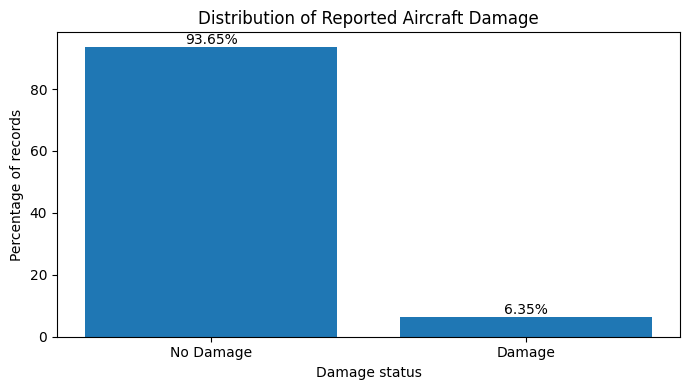

In [162]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    damage_distribution["Damage_Status"],
    damage_distribution["Percentage"]
)

ax.set_title("Distribution of Reported Aircraft Damage")
ax.set_xlabel("Damage status")
ax.set_ylabel("Percentage of records")

for index, value in enumerate(
    damage_distribution["Percentage"]
):
    ax.text(
        index,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Observation

Aircraft damage was reported in 21,810 records, representing 6.35% of the analysis dataset. The remaining 321,760 records, or 93.65%, indicated no aircraft damage. This confirms a substantial class imbalance between damage and no-damage outcomes.

## 6. Temporal Patterns

### 6.1 Reported Strikes and Damage Rate by Year

Annual strike counts and damage rates are summarized to examine changes in reported wildlife-strike activity over time.

In [163]:
yearly_summary = (
    analysis_df
    .groupby("INCIDENT_YEAR")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reset_index()
)

yearly_summary["Damage_Rate_Pct"] = (
    yearly_summary["Damage_Rate"] * 100
)

display(yearly_summary.tail(10))

,INCIDENT_YEAR,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
26,2016,13379,598,0.044697,4.469691
27,2017,14758,681,0.046144,4.614446
28,2018,16207,725,0.044734,4.473376
29,2019,17348,765,0.044097,4.409730
30,2020,11625,493,0.042409,4.240860
31,2021,15641,667,0.042644,4.264433
32,2022,17223,702,0.040759,4.075945
33,2023,19625,721,0.036739,3.673885
34,2024,22371,823,0.036789,3.678870
35,2025,24459,902,0.036878,3.687804


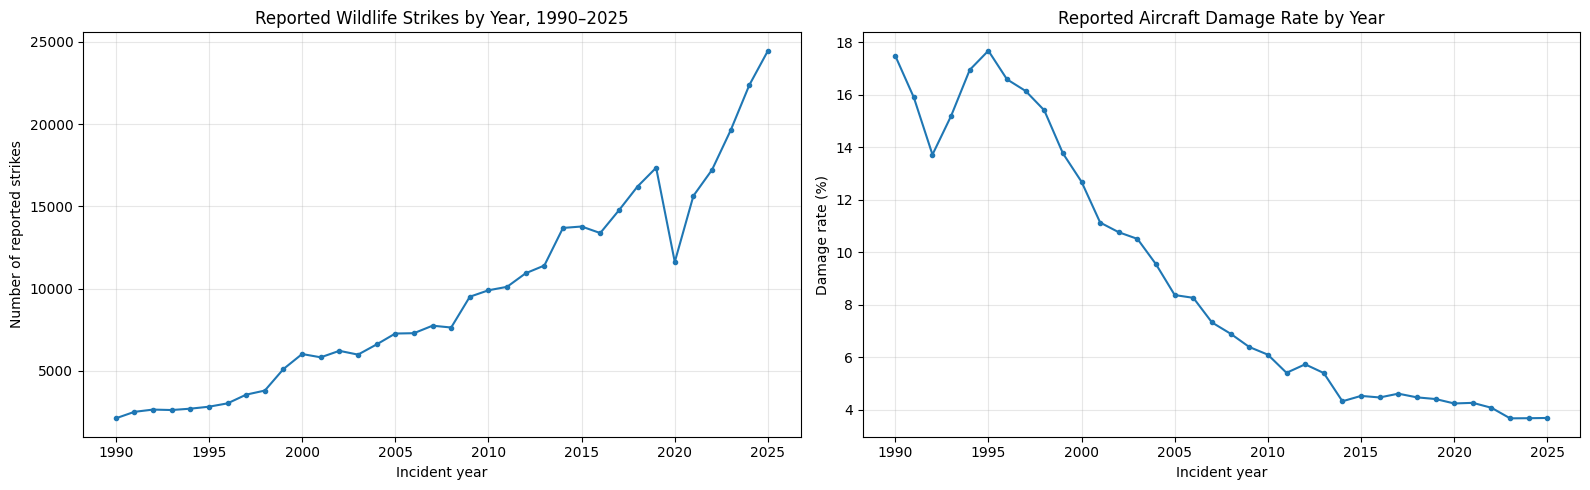

In [164]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

# Reported strike counts
axes[0].plot(
    yearly_summary["INCIDENT_YEAR"],
    yearly_summary["Reported_Strikes"],
    marker="o",
    markersize=3
)

axes[0].set_title(
    "Reported Wildlife Strikes by Year, 1990–2025"
)
axes[0].set_xlabel("Incident year")
axes[0].set_ylabel("Number of reported strikes")
axes[0].grid(alpha=0.3)

# Damage rate
axes[1].plot(
    yearly_summary["INCIDENT_YEAR"],
    yearly_summary["Damage_Rate_Pct"],
    marker="o",
    markersize=3
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by Year"
)
axes[1].set_xlabel("Incident year")
axes[1].set_ylabel("Damage rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observation

The number of reported wildlife strikes increased substantially over the analysis period, rising from fewer than 2,000 records in 1990 to 24,459 records in 2025. A temporary decline occurred in 2020, followed by a strong recovery and continued growth through 2025.

In contrast, the reported aircraft damage rate declined over time. The rate was above 15% during several years in the early 1990s but fell to approximately 3.7% by 2023–2025. Therefore, the increase in reported strike volume was not accompanied by a similar increase in the proportion of strikes resulting in aircraft damage.

### 6.2 Monthly and Seasonal Patterns

Reported strike counts and damage rates are summarized by incident month and season to examine recurring temporal patterns within each year.

In [165]:
month_order = list(range(1, 13))

monthly_summary = (
    analysis_df
    .groupby("INCIDENT_MONTH")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(month_order)
    .reset_index()
)

monthly_summary["Damage_Rate_Pct"] = (
    monthly_summary["Damage_Rate"] * 100
)

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_summary["Month"] = (
    monthly_summary["INCIDENT_MONTH"]
    .map(month_names)
)

display(
    monthly_summary[
        [
            "INCIDENT_MONTH",
            "Month",
            "Reported_Strikes",
            "Damage_Records",
            "Damage_Rate_Pct"
        ]
    ]
)

,INCIDENT_MONTH,Month,Reported_Strikes,Damage_Records,Damage_Rate_Pct
0,1,January,10830,1159,10.701754
1,2,February,10373,1083,10.440567
2,3,March,16067,1889,11.757017
3,4,April,24345,1918,7.878414
4,5,May,33854,1684,4.974301
5,6,June,28668,1262,4.402121
6,7,July,43710,1544,3.532372
7,8,August,48115,2063,4.287644
8,9,September,46599,2447,5.251186
9,10,October,43778,2865,6.544383


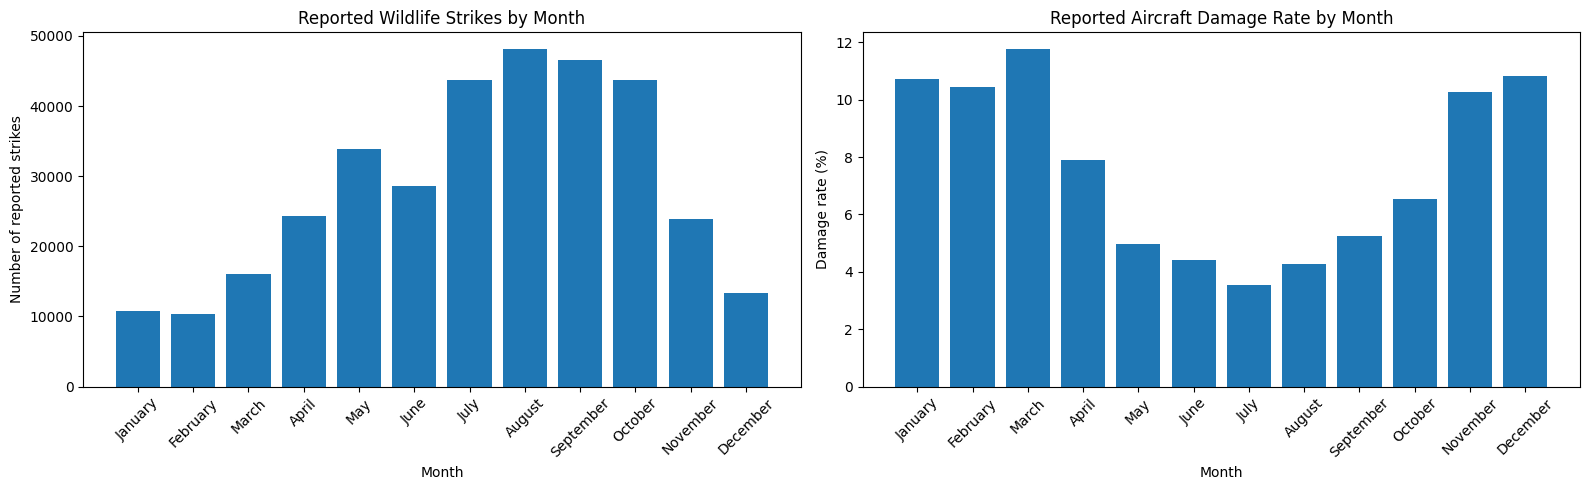

In [166]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

# Reported strike counts
axes[0].bar(
    monthly_summary["Month"],
    monthly_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Wildlife Strikes by Month"
)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of reported strikes")
axes[0].tick_params(
    axis="x",
    rotation=45
)

# Damage rate
axes[1].bar(
    monthly_summary["Month"],
    monthly_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by Month"
)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Damage rate (%)")
axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()
plt.show()

#### Observation

Reported wildlife strikes show a strong seasonal pattern. Strike volume was highest from July to October, peaking in August with 48,115 reported records, while the lowest monthly volumes occurred during the winter months.

The monthly damage rate followed a different pattern. March recorded the highest damage rate at 11.76%, followed by December, January, February, and November, all above 10%. In contrast, July had the lowest damage rate at 3.53%. This indicates that months with the highest strike volumes did not necessarily have the highest proportion of damaging incidents.

### 6.3 Seasonal Patterns

Reported strike counts and damage rates are summarized by season to compare overall seasonal differences.

In [167]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall"
]

seasonal_summary = (
    analysis_df
    .groupby("SEASON")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(season_order)
    .reset_index()
)

seasonal_summary["Damage_Rate_Pct"] = (
    seasonal_summary["Damage_Rate"] * 100
)

display(seasonal_summary)

,SEASON,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Winter,34594,3690,0.106666,10.666590
1,Spring,74266,5491,0.073937,7.393693
2,Summer,120493,4869,0.040409,4.040899
3,Fall,114217,7760,0.067941,6.794085


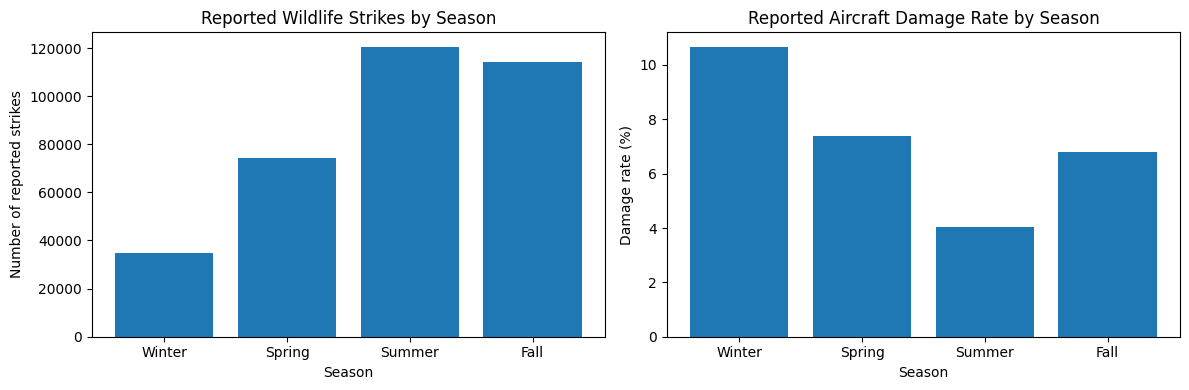

In [168]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].bar(
    seasonal_summary["SEASON"],
    seasonal_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Wildlife Strikes by Season"
)
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Number of reported strikes")

axes[1].bar(
    seasonal_summary["SEASON"],
    seasonal_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by Season"
)
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Reported wildlife strikes were most frequent in Summer and Fall, with 120,493 and 114,217 records, respectively. Winter had the lowest strike volume, with 34,594 reported records.

However, Winter had the highest aircraft damage rate at 10.67%, while Summer had the lowest rate at 4.04%. This shows that the season with the highest strike volume did not have the highest proportion of damaging incidents.

### 6.4 Day-of-Week and Time-of-Day Patterns

Reported strike counts and damage rates are summarized by day of the week and time of day to examine short-term temporal patterns.

In [169]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_summary = (
    analysis_df
    .groupby("DAY_OF_WEEK")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(day_order)
    .reset_index()
)

day_summary["Damage_Rate_Pct"] = (
    day_summary["Damage_Rate"] * 100
)

display(day_summary)

,DAY_OF_WEEK,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Monday,50415,3106,0.061609,6.160865
1,Tuesday,51330,3202,0.062381,6.238067
2,Wednesday,51483,3241,0.062953,6.295282
3,Thursday,53042,3351,0.063176,6.317635
4,Friday,51367,3285,0.063952,6.395156
5,Saturday,42076,2779,0.066047,6.604715
6,Sunday,43857,2846,0.064893,6.489272


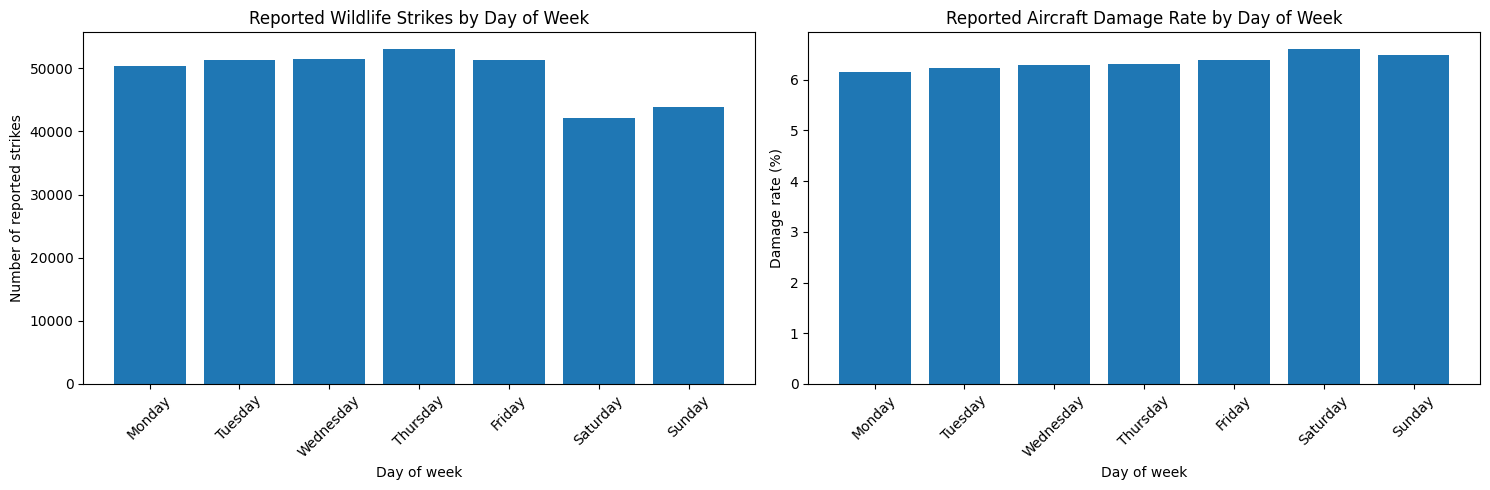

In [170]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].bar(
    day_summary["DAY_OF_WEEK"],
    day_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Wildlife Strikes by Day of Week"
)
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Number of reported strikes")
axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[1].bar(
    day_summary["DAY_OF_WEEK"],
    day_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by Day of Week"
)
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Damage rate (%)")
axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()
plt.show()

#### Observation

Reported strike counts were relatively similar from Monday to Friday, ranging from approximately 50,000 to 53,000 records, while Saturday and Sunday had lower volumes. Damage rates varied only slightly across the week, from 6.16% on Monday to 6.60% on Saturday. Overall, the day of the week appears to have limited descriptive variation in aircraft damage rates.

In [171]:
time_order = [
    "Dawn",
    "Day",
    "Dusk",
    "Night",
    "Unknown"
]

time_summary = (
    analysis_df
    .groupby("TIME_OF_DAY")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(time_order)
    .reset_index()
)

time_summary["Damage_Rate_Pct"] = (
    time_summary["Damage_Rate"] * 100
)

display(time_summary)

,TIME_OF_DAY,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Dawn,6632,572,0.086248,8.624849
1,Day,118145,10214,0.086453,8.645309
2,Dusk,8517,945,0.110955,11.095456
3,Night,60558,5975,0.098666,9.866574
4,Unknown,149718,4104,0.027412,2.741153


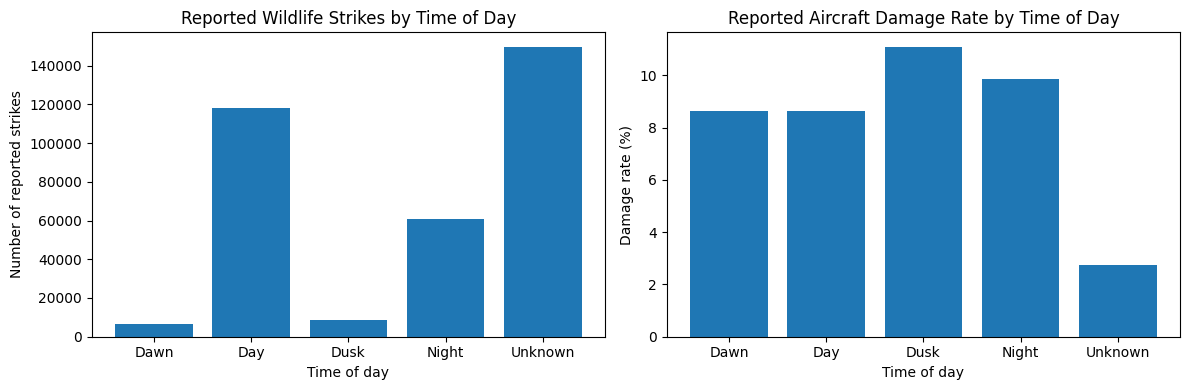

In [172]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].bar(
    time_summary["TIME_OF_DAY"],
    time_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Wildlife Strikes by Time of Day"
)
axes[0].set_xlabel("Time of day")
axes[0].set_ylabel("Number of reported strikes")

axes[1].bar(
    time_summary["TIME_OF_DAY"],
    time_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by Time of Day"
)
axes[1].set_xlabel("Time of day")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Time-of-day patterns showed greater variation than day-of-week patterns. Dusk had the highest damage rate at 11.10%, followed by Night at 9.87%, while Dawn and Day were both approximately 8.6%.

The `Unknown` category contained the largest number of records, with 149,718 reported strikes, but had a substantially lower damage rate of 2.74%. Because this category represents unavailable time-of-day information, its result should be interpreted cautiously and kept separate from the known time categories.

## 7. Geographic Patterns

This section summarizes reported strike counts and aircraft damage rates across FAA regions, incident states, and airports.

### 7.1 FAA Region

Reported strike counts and damage rates are summarized by FAA region. Records with unavailable region information are retained as `Unknown` and interpreted separately.

In [173]:
region_summary = (
    analysis_df
    .groupby("FAAREGION")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reset_index()
)

region_summary["Damage_Rate_Pct"] = (
    region_summary["Damage_Rate"] * 100
)

region_summary = (
    region_summary
    .sort_values("Reported_Strikes", ascending=False)
    .reset_index(drop=True)
)

display(region_summary)

,FAAREGION,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,ASO,66566,4139,0.062179,6.217889
1,AGL,47151,2767,0.058684,5.868380
2,AEA,46617,3257,0.069867,6.986722
3,ASW,41774,2190,0.052425,5.242495
4,Unknown,40068,2748,0.068583,6.858341
5,AWP,37015,2538,0.068567,6.856680
6,ANM,31793,1794,0.056428,5.642752
7,ACE,14098,943,0.066889,6.688892
8,ANE,11051,687,0.062166,6.216632
9,FGN,5700,484,0.084912,8.491228


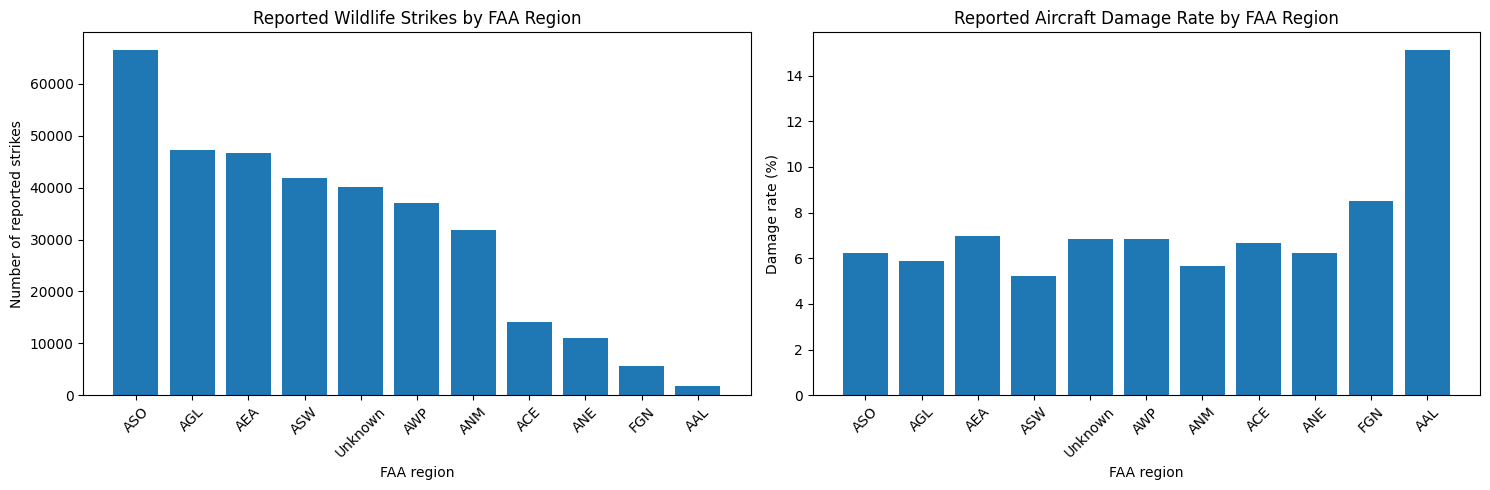

In [174]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].bar(
    region_summary["FAAREGION"],
    region_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Wildlife Strikes by FAA Region"
)
axes[0].set_xlabel("FAA region")
axes[0].set_ylabel("Number of reported strikes")
axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[1].bar(
    region_summary["FAAREGION"],
    region_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by FAA Region"
)
axes[1].set_xlabel("FAA region")
axes[1].set_ylabel("Damage rate (%)")
axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()
plt.show()

#### Observation

The Southern region (`ASO`) recorded the highest number of reported wildlife strikes, with 66,566 records, followed by `AGL` and `AEA`. In contrast, `AAL` had the smallest reporting volume, with 1,737 records.

Damage rates were generally between approximately 5% and 7% across most FAA regions. `AAL` showed the highest damage rate at 15.14%, followed by `FGN` at 8.49%. However, these regions had relatively small numbers of reported strikes, so their rates should be interpreted cautiously. The `Unknown` region contained 40,068 records and had a damage rate of 6.86%, similar to several known regions.

### 7.2 Incident State

Reported strike counts and damage rates are summarized by incident state. To support meaningful comparison, the charts focus on states with the largest reporting volumes, while records with unavailable state information are presented separately.

In [175]:
state_summary = (
    analysis_df
    .groupby("INCIDENT_STATE")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reset_index()
)

state_summary["Damage_Rate_Pct"] = (
    state_summary["Damage_Rate"] * 100
)

state_summary = (
    state_summary
    .sort_values("Reported_Strikes", ascending=False)
    .reset_index(drop=True)
)

display(state_summary.head(15))

,INCIDENT_STATE,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Unknown,40067,2748,0.068585,6.858512
1,TX,31309,1480,0.047271,4.727075
2,FL,25726,2148,0.083495,8.349530
3,CA,24545,1967,0.080139,8.013852
4,NY,16302,1039,0.063735,6.373451
5,CO,15097,449,0.029741,2.974101
6,IL,13994,719,0.051379,5.137916
7,TN,10579,406,0.038378,3.837792
8,OH,9338,489,0.052367,5.236667
9,PA,9273,586,0.063194,6.319422


In [176]:
# Top 10 excluding "Unknown"
top_states = (
    state_summary[
        state_summary["INCIDENT_STATE"] != "Unknown"
    ]
    .head(10)
    .copy()
)

display(top_states)

,INCIDENT_STATE,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
1,TX,31309,1480,0.047271,4.727075
2,FL,25726,2148,0.083495,8.349530
3,CA,24545,1967,0.080139,8.013852
4,NY,16302,1039,0.063735,6.373451
5,CO,15097,449,0.029741,2.974101
6,IL,13994,719,0.051379,5.137916
7,TN,10579,406,0.038378,3.837792
8,OH,9338,489,0.052367,5.236667
9,PA,9273,586,0.063194,6.319422
10,MI,8559,458,0.053511,5.351092


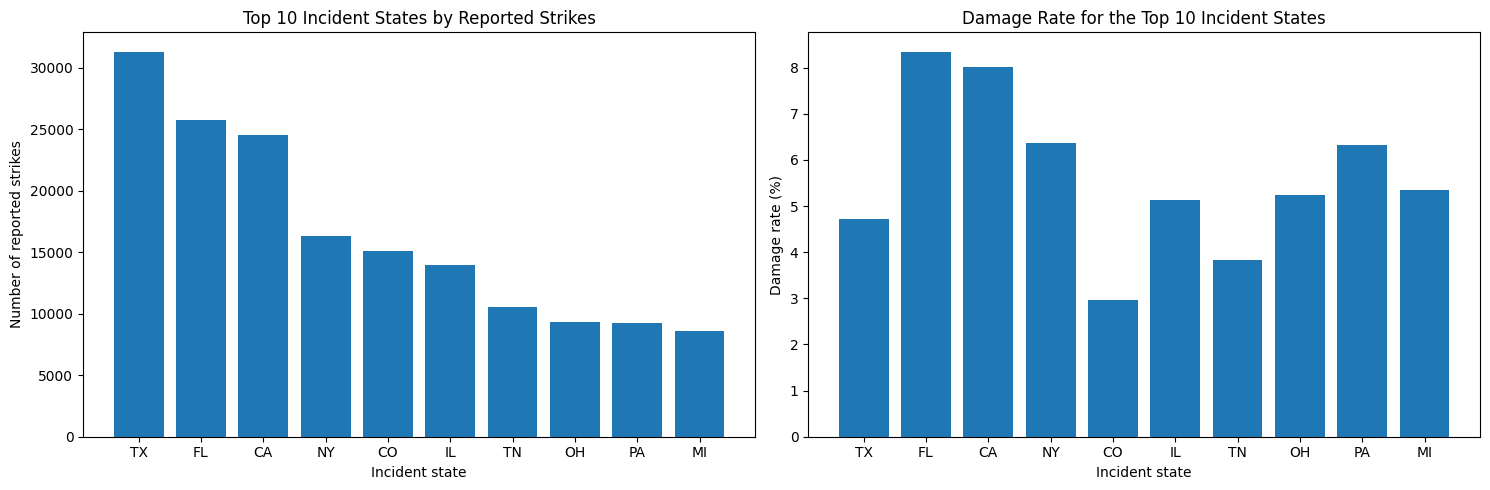

In [177]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].bar(
    top_states["INCIDENT_STATE"],
    top_states["Reported_Strikes"]
)

axes[0].set_title(
    "Top 10 Incident States by Reported Strikes"
)
axes[0].set_xlabel("Incident state")
axes[0].set_ylabel("Number of reported strikes")

axes[1].bar(
    top_states["INCIDENT_STATE"],
    top_states["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Damage Rate for the Top 10 Incident States"
)
axes[1].set_xlabel("Incident state")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Among the ten states with the largest reporting volumes, Texas recorded the highest number of reported wildlife strikes, with 31,309 records, followed by Florida and California. However, Texas had a lower damage rate of 4.73% than Florida and California, which recorded damage rates of 8.35% and 8.01%, respectively.

Colorado had the lowest damage rate among the top ten states at 2.97%, while Florida had the highest. The `Unknown` state category contained 40,067 records and had a damage rate of 6.86%, so it should remain separate from comparisons among identified states.

### 7.3 Airports

Reported strike counts and damage rates are summarized for airports with the largest reporting volumes. Unknown or non-specific airport identifiers are excluded from the top-airport ranking.

In [178]:
airport_summary = (
    analysis_df
    .groupby(["AIRPORT_ID", "AIRPORT"])
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reset_index()
)

airport_summary["Damage_Rate_Pct"] = (
    airport_summary["Damage_Rate"] * 100
)

invalid_airport_ids = [
    "UNKNOWN",
    "UNK",
    "ZZZZ"
]

airport_summary_valid = airport_summary[
    ~airport_summary["AIRPORT_ID"]
    .astype("string")
    .str.upper()
    .isin(invalid_airport_ids)
].copy()

top_airports = (
    airport_summary_valid
    .sort_values("Reported_Strikes", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_airports)

,AIRPORT_ID,AIRPORT,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,KDEN,DENVER INTL AIRPORT,11549,252,0.021820,2.182007
1,KDFW,DALLAS/FORT WORTH INTL ARPT,8902,277,0.031117,3.111660
2,KORD,CHICAGO O'HARE INTL ARPT,7290,271,0.037174,3.717421
3,KJFK,JOHN F KENNEDY INTL,6670,332,0.049775,4.977511
4,KMEM,MEMPHIS INTL,5475,198,0.036164,3.616438
5,KSLC,SALT LAKE CITY INTL,4367,377,0.086329,8.632929
6,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,4304,146,0.033922,3.392193
7,KDTW,DETROIT METRO WAYNE COUNTY ARPT,4298,116,0.026989,2.698930
8,KSMF,SACRAMENTO INTL,4263,483,0.113300,11.330049
9,KMCO,ORLANDO INTL,4223,312,0.073881,7.388113


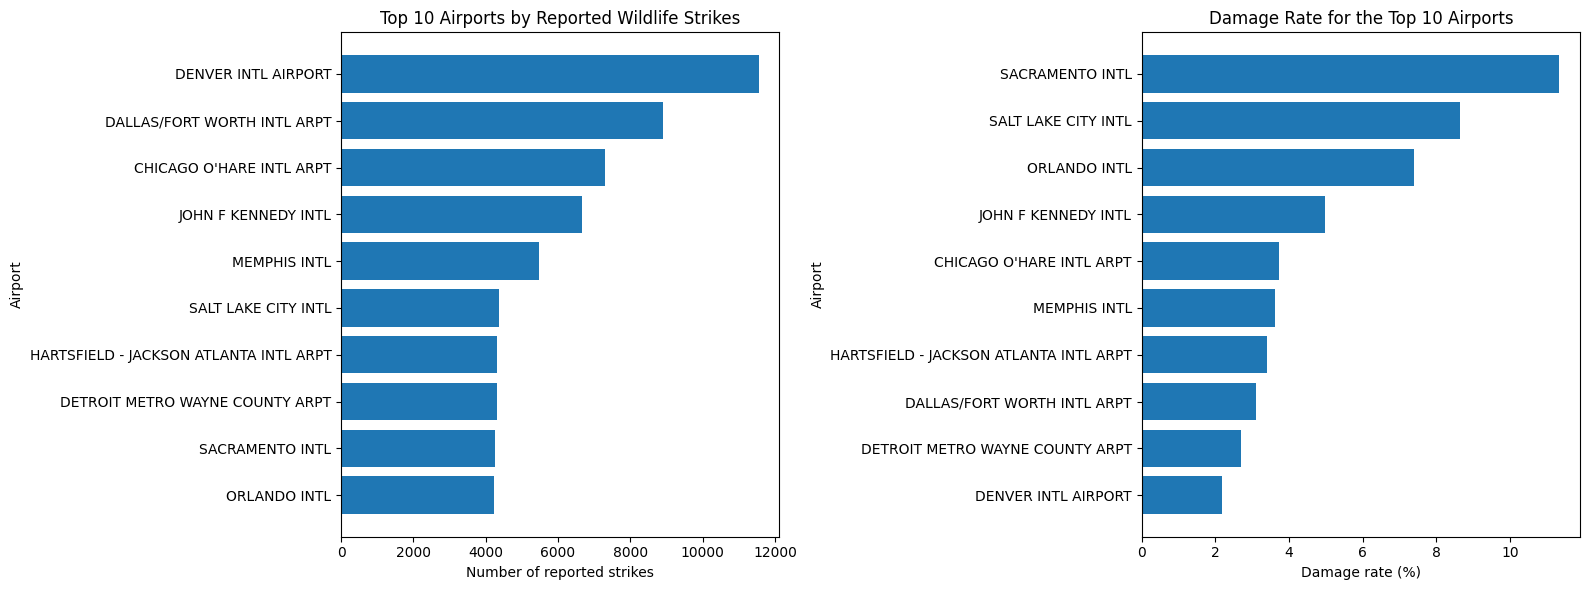

In [179]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

plot_order = top_airports.sort_values(
    "Reported_Strikes",
    ascending=True
)

axes[0].barh(
    plot_order["AIRPORT"],
    plot_order["Reported_Strikes"]
)

axes[0].set_title(
    "Top 10 Airports by Reported Wildlife Strikes"
)
axes[0].set_xlabel("Number of reported strikes")
axes[0].set_ylabel("Airport")

rate_order = top_airports.sort_values(
    "Damage_Rate_Pct",
    ascending=True
)

axes[1].barh(
    rate_order["AIRPORT"],
    rate_order["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Damage Rate for the Top 10 Airports"
)
axes[1].set_xlabel("Damage rate (%)")
axes[1].set_ylabel("Airport")

plt.tight_layout()
plt.show()

#### Observation

Denver International Airport recorded the highest number of reported wildlife strikes among the ten leading airports, with 11,549 records. It was followed by Dallas/Fort Worth International Airport and Chicago O’Hare International Airport.

However, the airports with the highest reporting volumes did not necessarily have the highest damage rates. Sacramento International Airport had the highest damage rate among the top ten airports at 11.33%, followed by Salt Lake City International Airport at 8.63% and Orlando International Airport at 7.39%. Denver International Airport had the lowest damage rate in this group at 2.18%.

### 7.4 Geographic Distribution of Reported Strikes

Airport coordinates were used to visualize the geographic distribution of reported wildlife strikes. Panel (a) focuses on the contiguous United States, where the main concentration of reporting activity is observed more clearly. Panel (b) shows the full geographic coverage, including Alaska, Hawaii, and airports outside the contiguous United States.

Each point represents an airport with available coordinate information. Point size reflects the number of reported strikes, while point color reflects the reported aircraft damage rate.

In [180]:
coordinate_columns = [
    column
    for column in analysis_df.columns
    if any(
        keyword in column.upper()
        for keyword in [
            "LAT",
            "LON",
            "LONG",
            "COORD"
        ]
    )
]

print(coordinate_columns)

['AIRPORT_LATITUDE', 'AIRPORT_LONGITUDE']


In [181]:
airport_geo_summary = (
    analysis_df[
        analysis_df["AIRPORT_LATITUDE"].notna()
        & analysis_df["AIRPORT_LONGITUDE"].notna()
        & analysis_df["AIRPORT_ID"].notna()
    ]
    .groupby(
        [
            "AIRPORT_ID",
            "AIRPORT",
            "AIRPORT_LATITUDE",
            "AIRPORT_LONGITUDE"
        ],
        dropna=False
    )
    .agg(
        Reported_Strikes=(
            "INDICATED_DAMAGE",
            "size"
        ),
        Damage_Records=(
            "INDICATED_DAMAGE",
            "sum"
        )
    )
    .reset_index()
)

airport_geo_summary["Damage_Rate_Percent"] = (
    airport_geo_summary["Damage_Records"]
    / airport_geo_summary["Reported_Strikes"]
    * 100
)

In [182]:
top_airport_geo_summary = (
    airport_geo_summary
    .sort_values(
        "Reported_Strikes",
        ascending=False
    )
    .head(10)
    [
        [
            "AIRPORT_ID",
            "AIRPORT",
            "Reported_Strikes",
            "Damage_Records",
            "Damage_Rate_Percent"
        ]
    ]
    .copy()
)

top_airport_geo_summary["Damage_Rate_Percent"] = (
    top_airport_geo_summary["Damage_Rate_Percent"]
    .round(2)
)

display(top_airport_geo_summary)

,AIRPORT_ID,AIRPORT,Reported_Strikes,Damage_Records,Damage_Rate_Percent
837,KDEN,DENVER INTL AIRPORT,11549,252,2.18
841,KDFW,DALLAS/FORT WORTH INTL ARPT,8902,277,3.11
1571,KORD,CHICAGO O'HARE INTL ARPT,7290,271,3.72
1252,KJFK,JOHN F KENNEDY INTL,6670,332,4.98
1399,KMEM,MEMPHIS INTL,5475,198,3.62
1824,KSLC,SALT LAKE CITY INTL,4367,377,8.63
582,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,4304,146,3.39
873,KDTW,DETROIT METRO WAYNE COUNTY ARPT,4298,116,2.70
1833,KSMF,SACRAMENTO INTL,4263,483,11.33
1388,KMCO,ORLANDO INTL,4223,312,7.39


#### Observation

Denver International Airport recorded the highest number of reported wildlife strikes, with 11,549 records, followed by Dallas/Fort Worth International Airport and Chicago O’Hare International Airport.

However, the airports with the highest strike volumes did not necessarily have the highest damage rates. Sacramento International Airport had the highest damage rate among the ten leading airports at 11.33%, followed by Salt Lake City International Airport at 8.63% and Orlando International Airport at 7.39%. Denver International Airport had the lowest damage rate in this group at 2.18%.

In [183]:
world_url = (
    "https://raw.githubusercontent.com/"
    "nvkelso/natural-earth-vector/master/"
    "geojson/ne_110m_admin_0_countries.geojson"
)

airport_geo_gdf = gpd.GeoDataFrame(
    airport_geo_summary.copy(),
    geometry=gpd.points_from_xy(
        airport_geo_summary["AIRPORT_LONGITUDE"],
        airport_geo_summary["AIRPORT_LATITUDE"]
    ),
    crs="EPSG:4326"
)

world_url = (
    "https://raw.githubusercontent.com/"
    "nvkelso/natural-earth-vector/master/"
    "geojson/ne_110m_admin_0_countries.geojson"
)

world = gpd.read_file(world_url)

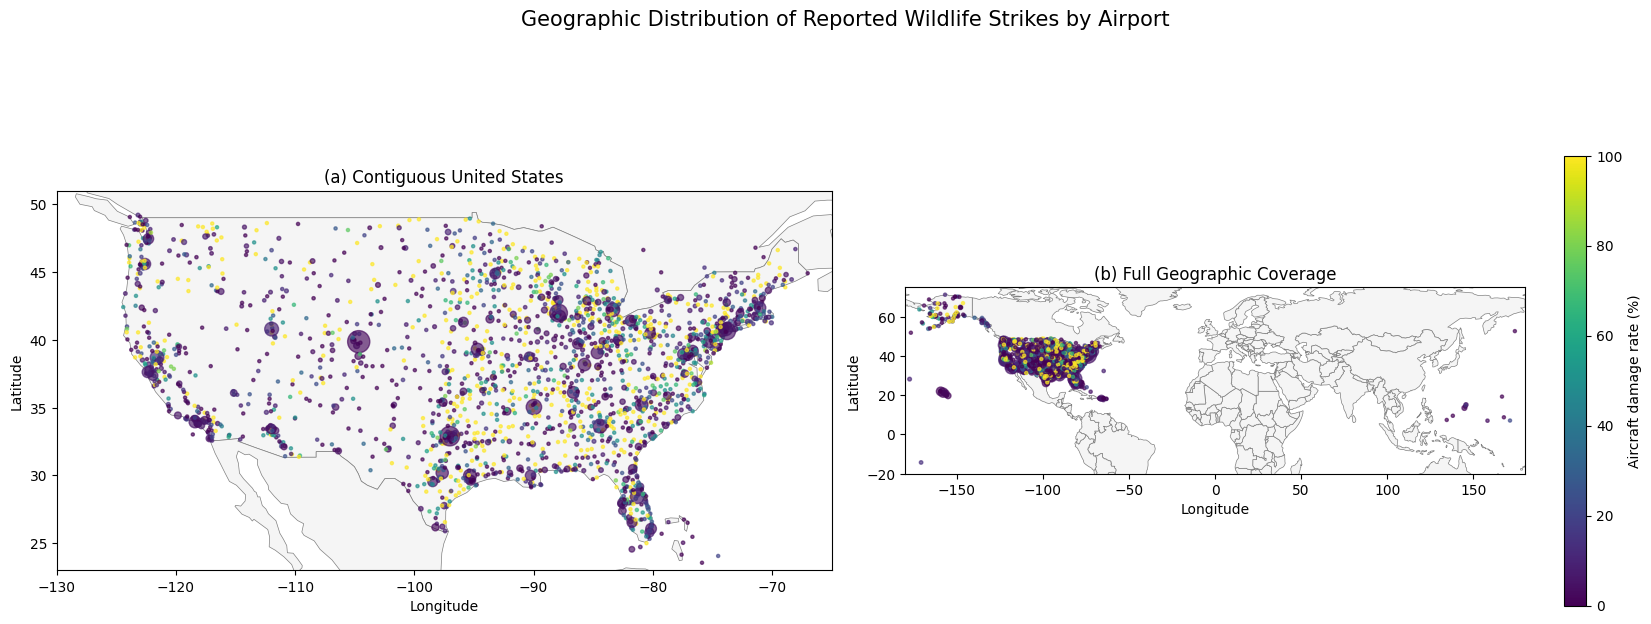

In [184]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(17, 7)
)

point_sizes = (
    airport_geo_gdf["Reported_Strikes"]
    / airport_geo_gdf["Reported_Strikes"].max()
    * 250
    + 5
)

# Use the same color scale for both panels
color_min = 0
color_max = airport_geo_gdf["Damage_Rate_Percent"].max()

# --------------------------------------------------
# (a) Contiguous United States
# --------------------------------------------------
world.plot(
    ax=axes[0],
    facecolor="whitesmoke",
    edgecolor="gray",
    linewidth=0.5
)

airport_geo_gdf.plot(
    ax=axes[0],
    column="Damage_Rate_Percent",
    markersize=point_sizes,
    alpha=0.65,
    vmin=color_min,
    vmax=color_max,
    legend=False
)

axes[0].set_xlim(-130, -65)
axes[0].set_ylim(23, 51)

axes[0].set_title(
    "(a) Contiguous United States"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# --------------------------------------------------
# (b) Full geographic coverage
# --------------------------------------------------
world.plot(
    ax=axes[1],
    facecolor="whitesmoke",
    edgecolor="gray",
    linewidth=0.5
)

airport_geo_gdf.plot(
    ax=axes[1],
    column="Damage_Rate_Percent",
    markersize=point_sizes,
    alpha=0.65,
    vmin=color_min,
    vmax=color_max,
    legend=True,
    legend_kwds={
        "label": "Aircraft damage rate (%)",
        "shrink": 0.75
    }
)

axes[1].set_xlim(-180, 180)
axes[1].set_ylim(-20, 75)

axes[1].set_title(
    "(b) Full Geographic Coverage"
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle(
    "Geographic Distribution of Reported Wildlife Strikes by Airport",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

#### Observation

The geographic distribution of reported wildlife strikes was heavily concentrated in the United States, particularly across the eastern half of the country, the Midwest, the Southeast, Texas, Florida, and parts of the West Coast. Reporting activity was also visible in Alaska, Hawaii, and a limited number of airports outside the contiguous United States.

The map indicates that reported strikes are not evenly distributed across airports. Instead, incidents are concentrated around a subset of high-traffic airports, while many smaller airports contribute relatively few reported records.

Differences in damage rate were also observed across airports. However, these color differences should be interpreted cautiously, especially for airports with relatively small reporting volumes, because damage rates can appear unstable when based on a limited number of incidents.

## 8. Wildlife Characteristics

This section summarizes reported strike counts and aircraft damage rates by wildlife size, species, and the reported number of animals struck.

### 8.1 Wildlife Size

Reported strike counts and damage rates are summarized by wildlife size. Records with unavailable size information are retained as `Unknown` and interpreted separately.

In [185]:
size_order = [
    "Small",
    "Medium",
    "Large",
    "Unknown"
]

size_summary = (
    analysis_df
    .groupby("SIZE")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(size_order)
    .reset_index()
)

size_summary["Damage_Rate_Pct"] = (
    size_summary["Damage_Rate"] * 100
)

display(size_summary)

,SIZE,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Small,212071,4258,0.020078,2.007818
1,Medium,73096,9196,0.125807,12.580716
2,Large,20550,6702,0.326131,32.613139
3,Unknown,37853,1654,0.043695,4.369535


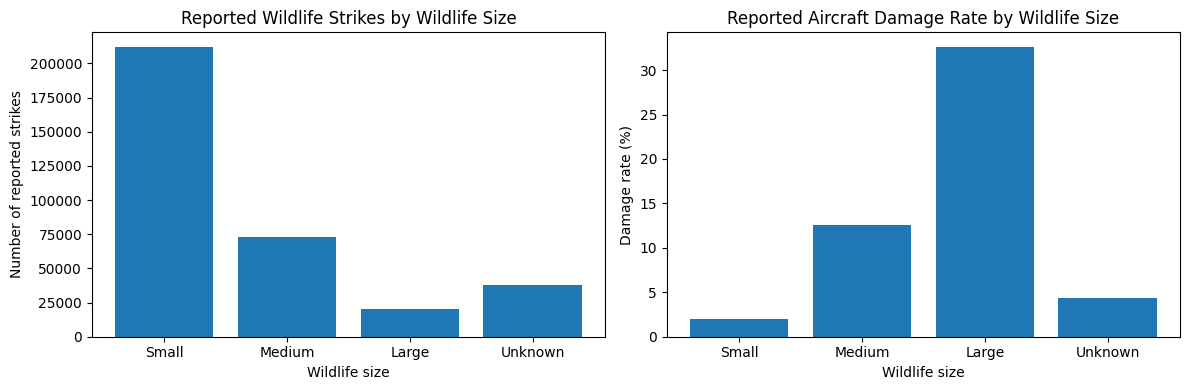

In [186]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].bar(
    size_summary["SIZE"],
    size_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Wildlife Strikes by Wildlife Size"
)
axes[0].set_xlabel("Wildlife size")
axes[0].set_ylabel("Number of reported strikes")

axes[1].bar(
    size_summary["SIZE"],
    size_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by Wildlife Size"
)
axes[1].set_xlabel("Wildlife size")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Small wildlife accounted for the largest number of reported strikes, with 212,071 records, but had the lowest aircraft damage rate at 2.01%. In contrast, large wildlife represented only 20,550 reported strikes but had the highest damage rate at 32.61%.

Medium wildlife had a damage rate of 12.58%, which was also substantially higher than the rate for small wildlife. The results show a clear descriptive increase in aircraft damage rate across the reported wildlife-size categories.

### 8.2 Wildlife Species and Species Groups

Reported strike counts and aircraft damage rates are summarized for the most frequently reported wildlife species. Species with very small numbers of records are not emphasized because their damage rates may be unstable.

### 8.2.1 Most Frequently Reported Identified Species or Groups

In [187]:
species_summary = (
    analysis_df
    .groupby("SPECIES")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reset_index()
)

species_summary["Damage_Rate_Pct"] = (
    species_summary["Damage_Rate"] * 100
)

species_summary = (
    species_summary
    .sort_values("Reported_Strikes", ascending=False)
    .reset_index(drop=True)
)

display(species_summary.head(20))

,SPECIES,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Unknown bird - small,54916,1424,0.025931,2.593051
1,Unknown bird - medium,39388,4608,0.116990,11.698995
2,Unknown bird,37385,1629,0.043574,4.357363
3,Mourning dove,17909,322,0.017980,1.797979
4,Barn swallow,11721,40,0.003413,0.341268
5,Killdeer,11434,84,0.007347,0.734651
6,American kestrel,10480,64,0.006107,0.610687
7,Horned lark,9910,50,0.005045,0.504541
8,Gulls,7666,1167,0.152231,15.223063
9,European starling,6976,170,0.024369,2.436927


In [188]:
display(
    species_summary[
        [
            "SPECIES",
            "Reported_Strikes",
            "Damage_Records",
            "Damage_Rate_Pct"
        ]
    ].head(20)
)

,SPECIES,Reported_Strikes,Damage_Records,Damage_Rate_Pct
0,Unknown bird - small,54916,1424,2.593051
1,Unknown bird - medium,39388,4608,11.698995
2,Unknown bird,37385,1629,4.357363
3,Mourning dove,17909,322,1.797979
4,Barn swallow,11721,40,0.341268
5,Killdeer,11434,84,0.734651
6,American kestrel,10480,64,0.610687
7,Horned lark,9910,50,0.504541
8,Gulls,7666,1167,15.223063
9,European starling,6976,170,2.436927


In [189]:
invalid_species_labels = [
    "UNKNOWN",
    "UNKNOWN BIRD",
    "UNKNOWN BIRD - SMALL",
    "UNKNOWN BIRD - MEDIUM",
    "UNKNOWN BIRD - LARGE"
]

top_species = (
    species_summary[
        ~species_summary["SPECIES"]
        .astype("string")
        .str.upper()
        .isin(invalid_species_labels)
    ]
    .head(10)
    .copy()
)

display(top_species)

,SPECIES,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
3,Mourning dove,17909,322,0.017980,1.797979
4,Barn swallow,11721,40,0.003413,0.341268
5,Killdeer,11434,84,0.007347,0.734651
6,American kestrel,10480,64,0.006107,0.610687
7,Horned lark,9910,50,0.005045,0.504541
8,Gulls,7666,1167,0.152231,15.223063
9,European starling,6976,170,0.024369,2.436927
10,Eastern meadowlark,5270,43,0.008159,0.815939
11,Rock pigeon,4770,326,0.068344,6.834382
12,Red-tailed hawk,4517,572,0.126633,12.663272


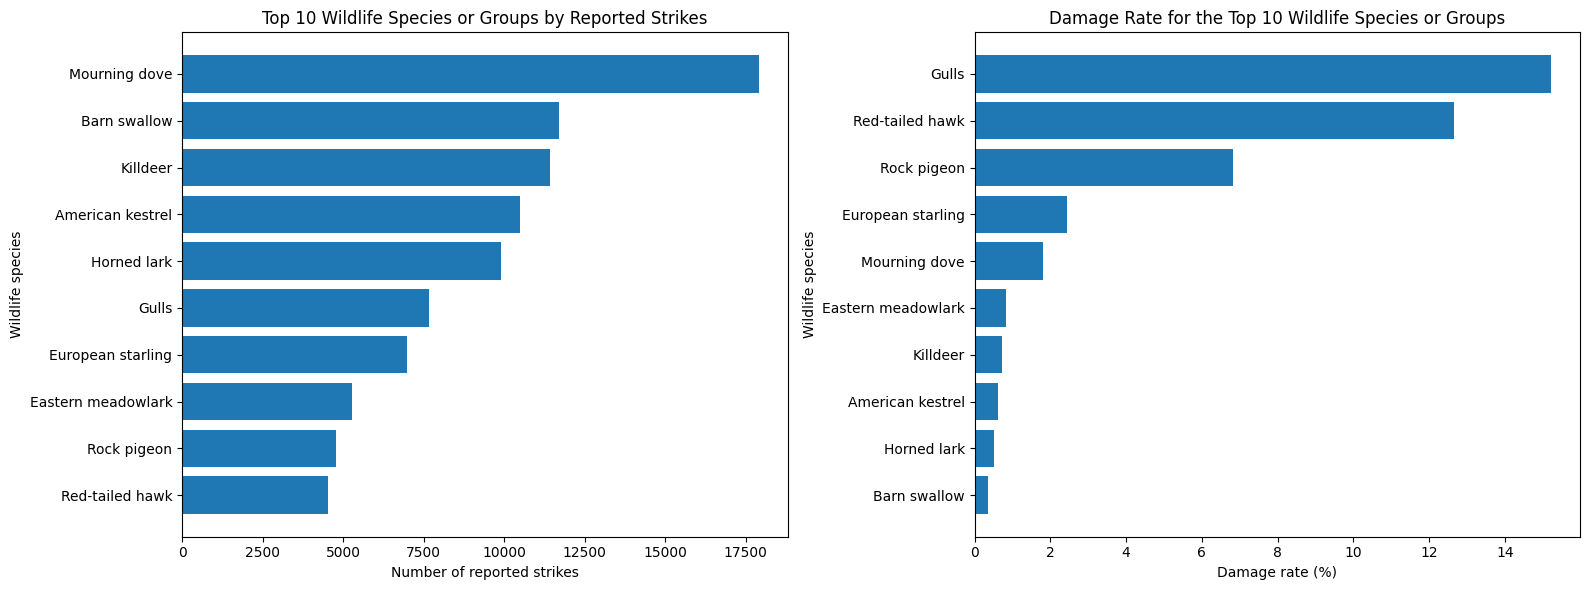

In [190]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

count_order = top_species.sort_values(
    "Reported_Strikes",
    ascending=True
)

axes[0].barh(
    count_order["SPECIES"],
    count_order["Reported_Strikes"]
)

axes[0].set_title(
    "Top 10 Wildlife Species or Groups by Reported Strikes"
)
axes[0].set_xlabel("Number of reported strikes")
axes[0].set_ylabel("Wildlife species")

rate_order = top_species.sort_values(
    "Damage_Rate_Pct",
    ascending=True
)

axes[1].barh(
    rate_order["SPECIES"],
    rate_order["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Damage Rate for the Top 10 Wildlife Species or Groups"
)
axes[1].set_xlabel("Damage rate (%)")
axes[1].set_ylabel("Wildlife species")

plt.tight_layout()
plt.show()

#### Observation

Mourning dove was the most frequently reported identified species, with 17,909 strike records, followed by barn swallow and killdeer. However, these frequently reported species generally had relatively low aircraft damage rates.

Among the ten most frequently reported identified species, gulls had the highest damage rate at 15.22%, followed by red-tailed hawk at 12.66% and rock pigeon at 6.83%. In contrast, barn swallow had the lowest damage rate at 0.34%. These results show that reporting frequency and aircraft damage rate varied substantially across species.

### 8.2.2 Records with Unidentified Wildlife Species

In [191]:
unknown_species_summary = (
    species_summary[
        species_summary["SPECIES"]
        .astype("string")
        .str.upper()
        .str.startswith("UNKNOWN")
    ]
    .copy()
)

display(unknown_species_summary)

,SPECIES,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Unknown bird - small,54916,1424,0.025931,2.593051
1,Unknown bird - medium,39388,4608,0.116990,11.698995
2,Unknown bird,37385,1629,0.043574,4.357363
14,Unknown bird - large,3986,1457,0.365529,36.552935
83,Unknown bird or bat,421,13,0.030879,3.087886
297,Unknown terrestrial mammal,46,12,0.260870,26.086957


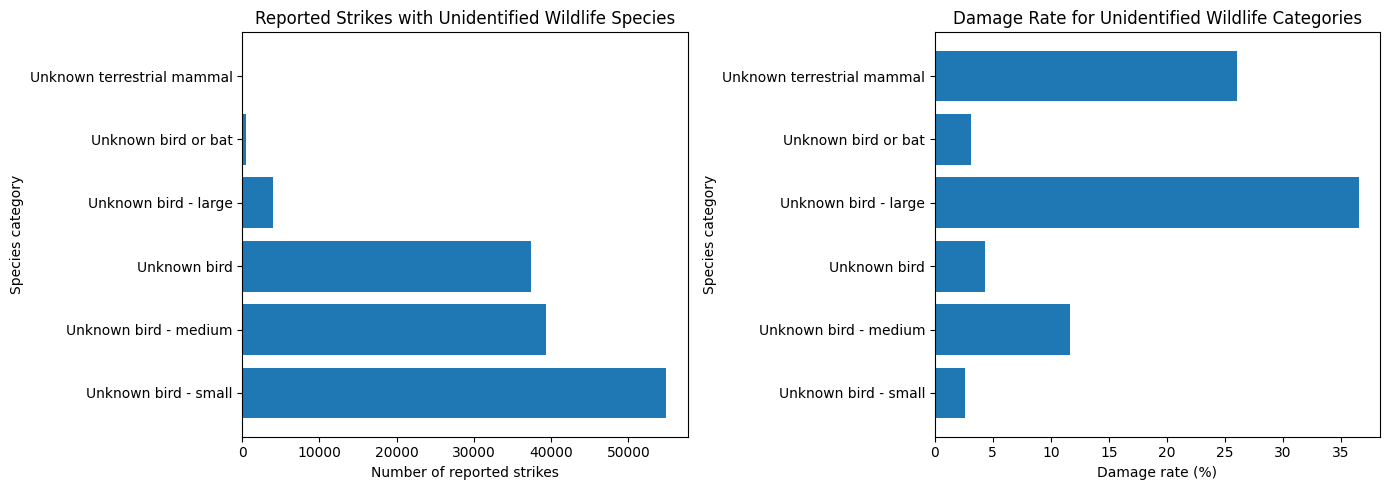

In [192]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].barh(
    unknown_species_summary["SPECIES"],
    unknown_species_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Strikes with Unidentified Wildlife Species"
)
axes[0].set_xlabel("Number of reported strikes")
axes[0].set_ylabel("Species category")

axes[1].barh(
    unknown_species_summary["SPECIES"],
    unknown_species_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Damage Rate for Unidentified Wildlife Categories"
)
axes[1].set_xlabel("Damage rate (%)")
axes[1].set_ylabel("Species category")

plt.tight_layout()
plt.show()

#### Observation

Unidentified wildlife categories accounted for a substantial number of reported strikes. `Unknown bird - small`, `Unknown bird - medium`, and `Unknown bird` were the most common unidentified categories, with 54,916, 39,388, and 37,385 records, respectively.

Damage rates varied considerably across these categories. `Unknown bird - large` had the highest damage rate at 36.55%, followed by `Unknown terrestrial mammal` at 26.09% and `Unknown bird - medium` at 11.70%. However, `Unknown terrestrial mammal` contained only 46 records, so its damage rate should be interpreted cautiously. These categories are reported separately because they do not identify a specific wildlife species.

### 8.3 Number of Wildlife Struck

The distribution of reported strike records and aircraft damage rates is summarized by the number of wildlife struck. Missing values are retained as a separate category because they represent unavailable information rather than a confirmed count.

In [193]:
analysis_df["NUM_STRUCK_DISPLAY"] = (
    analysis_df["NUM_STRUCK"]
    .fillna("Unknown")
    .astype("string")
)

num_struck_order = [
    "1",
    "2-10",
    "11-100",
    "More than 100",
    "Unknown"
]

num_struck_summary = (
    analysis_df
    .groupby("NUM_STRUCK_DISPLAY")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(num_struck_order)
    .reset_index()
)

num_struck_summary["Damage_Rate_Pct"] = (
    num_struck_summary["Damage_Rate"] * 100
)

display(num_struck_summary)

,NUM_STRUCK_DISPLAY,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,1,305725,17388,0.056875,5.687464
1,2-10,35400,3944,0.111412,11.141243
2,11-100,1662,331,0.199158,19.915764
3,More than 100,58,20,0.344828,34.482759
4,Unknown,725,127,0.175172,17.517241


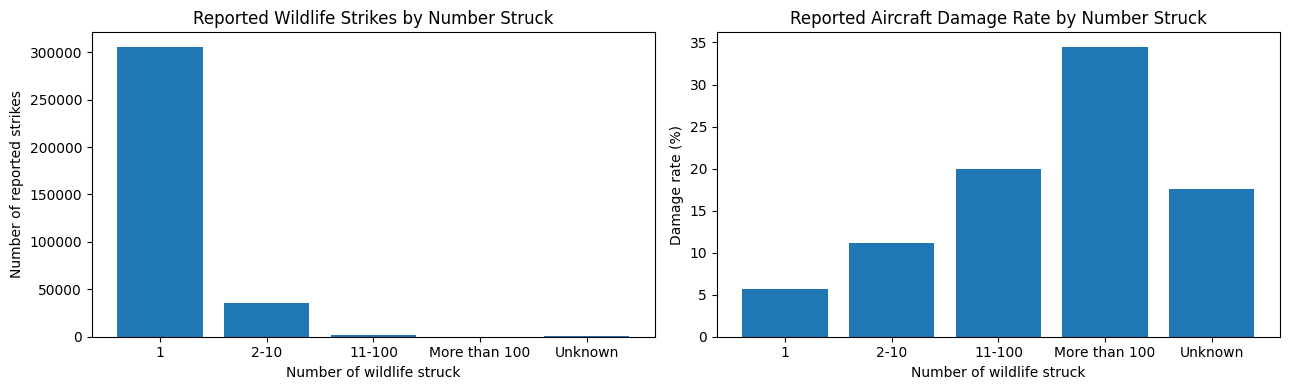

In [194]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

axes[0].bar(
    num_struck_summary["NUM_STRUCK_DISPLAY"],
    num_struck_summary["Reported_Strikes"]
)

axes[0].set_title(
    "Reported Wildlife Strikes by Number Struck"
)
axes[0].set_xlabel("Number of wildlife struck")
axes[0].set_ylabel("Number of reported strikes")

axes[1].bar(
    num_struck_summary["NUM_STRUCK_DISPLAY"],
    num_struck_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "Reported Aircraft Damage Rate by Number Struck"
)
axes[1].set_xlabel("Number of wildlife struck")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Most reported incidents involved one animal, accounting for 305,725 records, with a damage rate of 5.69%. The damage rate increased as the reported number struck increased, reaching 11.14% for 2-10 animals and 19.92% for 11-100 animals.

The `More than 100` category had the highest damage rate at 34.48%, but it contained only 58 records, so this estimate should be interpreted cautiously. Records with an unknown number struck also showed a relatively high damage rate of 17.52%.

## 9. Aircraft Characteristics

This section summarizes reported strike counts and aircraft damage rates by aircraft class, aircraft mass, engine type, and number of engines.

### 9.1 Aircraft Class

Reported strike counts and damage rates are summarized by aircraft class. Records with unavailable class information are retained as `Unknown` and interpreted separately.

The `AC_CLASS` variable uses the following aircraft-class codes:

| Code | Aircraft class |
|---|---|
| A | Airplane |
| B | Helicopter |
| C | Glider |
| D | Balloon |
| F | Dirigible |
| I | Gyroplane |
| J | Ultralight |
| Y | Other |
| Z | Unknown |

In [195]:
aircraft_class_labels = {
    "A": "Airplane",
    "B": "Helicopter",
    "C": "Glider",
    "D": "Balloon",
    "F": "Dirigible",
    "I": "Gyroplane",
    "J": "Ultralight",
    "Y": "Other",
    "Z": "Unknown"
}

analysis_df["AC_CLASS_DISPLAY"] = (
    analysis_df["AC_CLASS"]
    .map(aircraft_class_labels)
    .fillna("Unknown")
)

In [196]:
aircraft_class_summary = (
    analysis_df
    .groupby("AC_CLASS_DISPLAY")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reset_index()
)

aircraft_class_summary["Damage_Rate_Pct"] = (
    aircraft_class_summary["Damage_Rate"] * 100
)

aircraft_class_summary = (
    aircraft_class_summary
    .sort_values("Reported_Strikes", ascending=False)
    .reset_index(drop=True)
)

display(aircraft_class_summary)

,AC_CLASS_DISPLAY,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Airplane,241047,20555,0.085274,8.527383
1,Unknown,97190,276,0.002840,0.283980
2,Helicopter,5319,976,0.183493,18.349314
3,Glider,7,3,0.428571,42.857143
4,Ultralight,4,0,0.000000,0.000000
5,Other,3,0,0.000000,0.000000


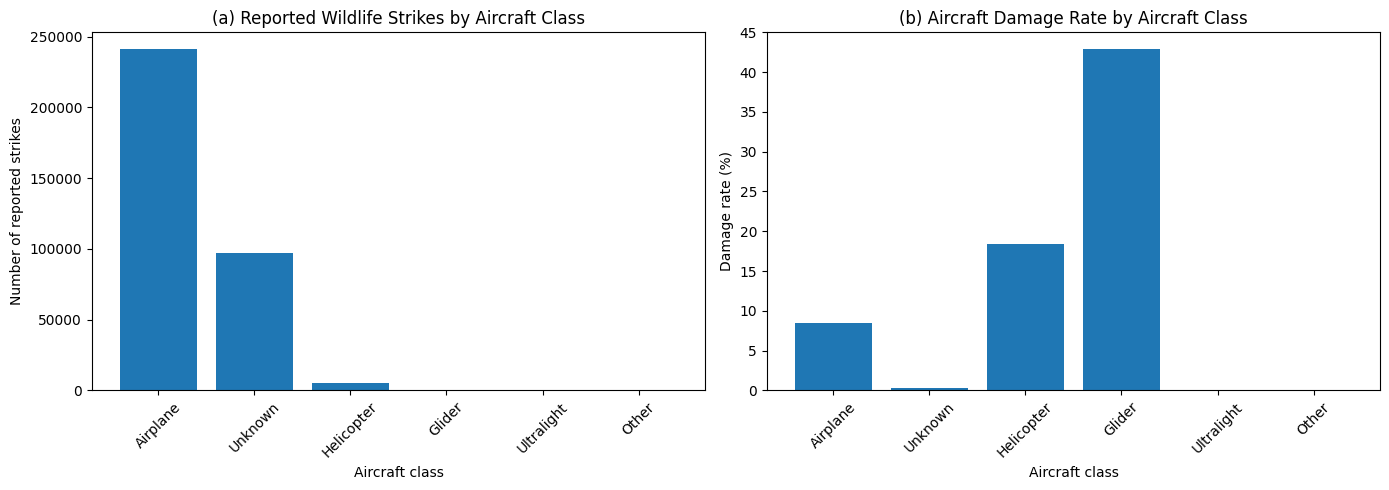

In [197]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].bar(
    aircraft_class_summary["AC_CLASS_DISPLAY"],
    aircraft_class_summary["Reported_Strikes"]
)

axes[0].set_title(
    "(a) Reported Wildlife Strikes by Aircraft Class"
)
axes[0].set_xlabel("Aircraft class")
axes[0].set_ylabel("Number of reported strikes")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(
    aircraft_class_summary["AC_CLASS_DISPLAY"],
    aircraft_class_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "(b) Aircraft Damage Rate by Aircraft Class"
)
axes[1].set_xlabel("Aircraft class")
axes[1].set_ylabel("Damage rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Observation

Airplanes accounted for the majority of reported wildlife strikes, with 241,047 records, followed by the `Unknown` category with 97,190 records. Helicopters represented a much smaller share of the dataset, with 5,319 records, while gliders, ultralights, and other aircraft classes contained very few observations.

Helicopters had a higher damage rate than airplanes, at 18.35% compared with 8.53%. Gliders showed the highest damage rate at 42.86%, but this result was based on only seven records and should not be interpreted as a stable estimate. The `Unknown` category had a very low damage rate of 0.28% and should be considered separately because aircraft-class information was unavailable for these records.

### 9.2 Aircraft Mass

Reported strike counts and aircraft damage rates are summarized by aircraft mass category. Missing values are retained as `Unknown` and interpreted separately.

In [198]:
analysis_df["AC_MASS"].value_counts(dropna=False).sort_index()

AC_MASS
1.0     14665
2.0     14990
3.0     37276
4.0    176556
5.0      2763
NaN     97320
Name: count, dtype: int64

### 9.2 Aircraft Mass Category

The `AC_MASS` variable is recorded using coded aircraft-mass categories:

| Code | Aircraft mass |
|---|---|
| 1 | 2,250 kg or less |
| 2 | 2,251–5,700 kg |
| 3 | 5,701–27,000 kg |
| 4 | 27,001–272,000 kg |
| 5 | More than 272,000 kg |

Reported strike counts and aircraft damage rates are summarized across these categories. Missing values are retained as `Unknown` and interpreted separately.

In [199]:
analysis_df["AC_MASS_DISPLAY"] = (
    analysis_df["AC_MASS"]
    .map({
        1.0: "1",
        2.0: "2",
        3.0: "3",
        4.0: "4",
        5.0: "5"
    })
    .fillna("Unknown")
)

mass_order = [
    "1",
    "2",
    "3",
    "4",
    "5",
    "Unknown"
]

In [200]:
aircraft_mass_summary = (
    analysis_df
    .groupby("AC_MASS_DISPLAY")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(mass_order)
    .reset_index()
)

aircraft_mass_summary["Damage_Rate_Pct"] = (
    aircraft_mass_summary["Damage_Rate"] * 100
)

display(aircraft_mass_summary)

,AC_MASS_DISPLAY,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,1,14665,3984,0.271667,27.166723
1,2,14990,3106,0.207205,20.720480
2,3,37276,3662,0.098240,9.824015
3,4,176556,10464,0.059267,5.926731
4,5,2763,407,0.147304,14.730366
5,Unknown,97320,187,0.001921,0.192150


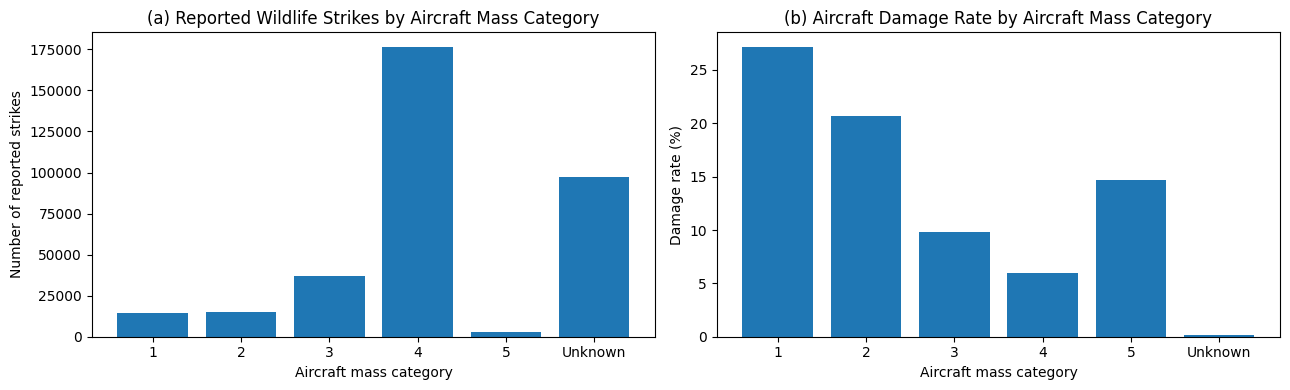

In [201]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

# Panel (a): reported strike counts
axes[0].bar(
    aircraft_mass_summary["AC_MASS_DISPLAY"],
    aircraft_mass_summary["Reported_Strikes"]
)

axes[0].set_title(
    "(a) Reported Wildlife Strikes by Aircraft Mass Category"
)
axes[0].set_xlabel("Aircraft mass category")
axes[0].set_ylabel("Number of reported strikes")

# Panel (b): damage rate
axes[1].bar(
    aircraft_mass_summary["AC_MASS_DISPLAY"],
    aircraft_mass_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "(b) Aircraft Damage Rate by Aircraft Mass Category"
)
axes[1].set_xlabel("Aircraft mass category")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Aircraft weighing 27,001–272,000 kg (category `4`) accounted for the largest number of reported wildlife strikes, with 176,556 records.

The highest damage rates were observed for aircraft weighing 2,250 kg or less (category `1`) and 2,251–5,700 kg (category `2`), at 27.17% and 20.72%, respectively. Aircraft in category `4`, despite having the largest reporting volume, had a lower damage rate of 5.93%. Aircraft above 272,000 kg (category `5`) had a damage rate of 14.73%, but this category contained only 2,763 records and should be interpreted cautiously.

The `Unknown` category had a very low damage rate of 0.19% and should be considered separately because aircraft-mass information was unavailable for these records.

### 9.3 Engine Type

The `TYPE_ENG` variable uses the following engine-type codes:

| Code | Engine type |
|---|---|
| A | Reciprocating engine (piston) |
| B | Turbojet |
| C | Turboprop |
| D | Turbofan |
| E | None (glider) |
| F | Turboshaft (helicopter) |
| Y | Other |

Reported strike counts and aircraft damage rates are summarized by engine type. Unavailable values are retained as `Unknown` and interpreted separately.

In [202]:
analysis_df["TYPE_ENG"].value_counts(dropna=False)

TYPE_ENG
D          208535
Unknown     97642
A           16267
C           15678
F            5014
B             426
E               5
Y               3
Name: count, dtype: int64

In [203]:
engine_type_labels = {
    "A": "Reciprocating (piston)",
    "B": "Turbojet",
    "C": "Turboprop",
    "D": "Turbofan",
    "E": "None (glider)",
    "F": "Turboshaft",
    "Y": "Other"
}

analysis_df["TYPE_ENG_DISPLAY"] = (
    analysis_df["TYPE_ENG"]
    .map(engine_type_labels)
    .fillna("Unknown")
)

In [204]:
engine_type_summary = (
    analysis_df
    .groupby("TYPE_ENG_DISPLAY")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reset_index()
)

engine_type_summary["Damage_Rate_Pct"] = (
    engine_type_summary["Damage_Rate"] * 100
)

engine_type_summary = (
    engine_type_summary
    .sort_values("Reported_Strikes", ascending=False)
    .reset_index(drop=True)
)

display(engine_type_summary)

,TYPE_ENG_DISPLAY,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Turbofan,208535,13856,0.066444,6.644448
1,Unknown,97642,331,0.003390,0.338993
2,Reciprocating (piston),16267,4339,0.266736,26.673634
3,Turboprop,15678,2289,0.146001,14.600077
4,Turboshaft,5014,887,0.176905,17.690467
5,Turbojet,426,105,0.246479,24.647887
6,None (glider),5,3,0.600000,60.000000
7,Other,3,0,0.000000,0.000000


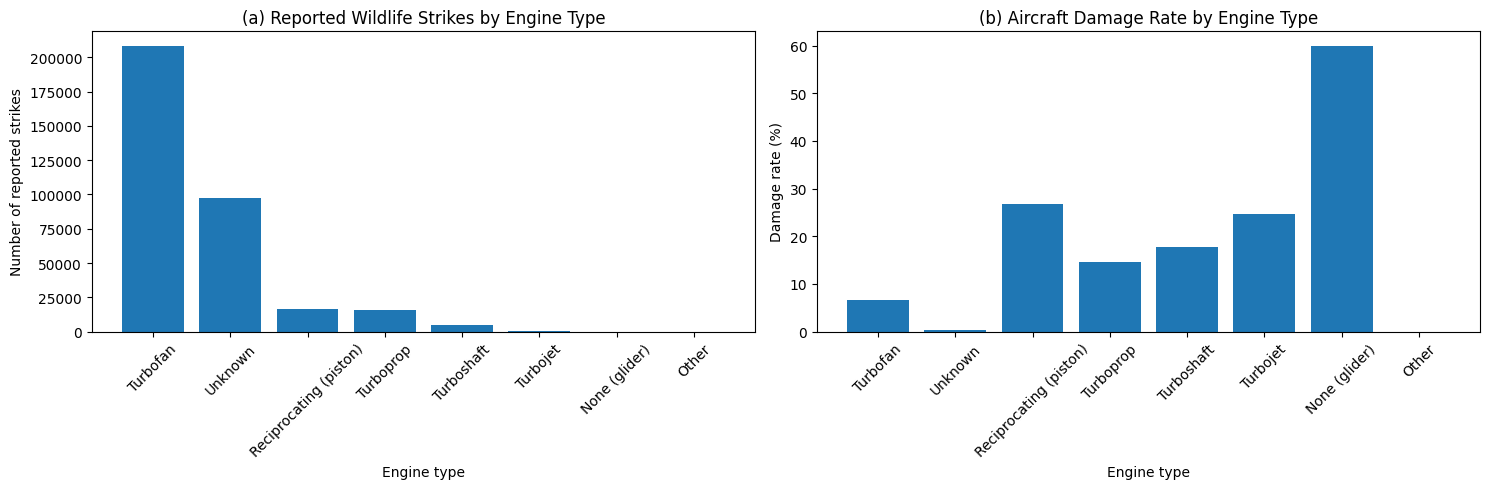

In [205]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

# Panel (a): reported strike counts
axes[0].bar(
    engine_type_summary["TYPE_ENG_DISPLAY"],
    engine_type_summary["Reported_Strikes"]
)

axes[0].set_title(
    "(a) Reported Wildlife Strikes by Engine Type"
)
axes[0].set_xlabel("Engine type")
axes[0].set_ylabel("Number of reported strikes")
axes[0].tick_params(
    axis="x",
    rotation=45
)

# Panel (b): damage rate
axes[1].bar(
    engine_type_summary["TYPE_ENG_DISPLAY"],
    engine_type_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "(b) Aircraft Damage Rate by Engine Type"
)
axes[1].set_xlabel("Engine type")
axes[1].set_ylabel("Damage rate (%)")
axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()
plt.show()

#### Observation

Turbofan aircraft accounted for the largest number of reported wildlife strikes, with 208,535 records, followed by the `Unknown` category with 97,642 records. Reciprocating engines and turboprops each contributed approximately 16,000 reported strikes, while the remaining engine types had much smaller reporting volumes.

Damage rates were highest for reciprocating engines at 26.67%, followed by turbojets at 24.65% and turboshaft engines at 17.69%. Turbofan aircraft, despite having the largest reporting volume, had a lower damage rate of 6.64%. The `None (glider)` category showed a damage rate of 60%, but this estimate was based on only five records and should not be treated as stable. The `Unknown` category should be interpreted separately because engine-type information was unavailable for these records.

### 9.4 Number of Engines

Reported strike counts and aircraft damage rates are summarized by the number of engines. Missing values are retained as `Unknown` and interpreted separately.

In [206]:
analysis_df["NUM_ENGS"].value_counts(dropna=False).sort_index()

NUM_ENGS
1.0     16410
2.0    215899
3.0     10027
4.0      3624
NaN     97610
Name: count, dtype: int64

In [207]:
analysis_df["NUM_ENGS_DISPLAY"] = (
    analysis_df["NUM_ENGS"]
    .map({
        1.0: "1",
        2.0: "2",
        3.0: "3",
        4.0: "4"
    })
    .fillna("Unknown")
)

num_engines_order = [
    "1",
    "2",
    "3",
    "4",
    "Unknown"
]

In [208]:
num_engines_summary = (
    analysis_df
    .groupby("NUM_ENGS_DISPLAY")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(num_engines_order)
    .reset_index()
)

num_engines_summary["Damage_Rate_Pct"] = (
    num_engines_summary["Damage_Rate"] * 100
)

display(num_engines_summary)

,NUM_ENGS_DISPLAY,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,1,16410,4156,0.253260,25.326021
1,2,215899,16037,0.074280,7.428010
2,3,10027,731,0.072903,7.290316
3,4,3624,552,0.152318,15.231788
4,Unknown,97610,334,0.003422,0.342178


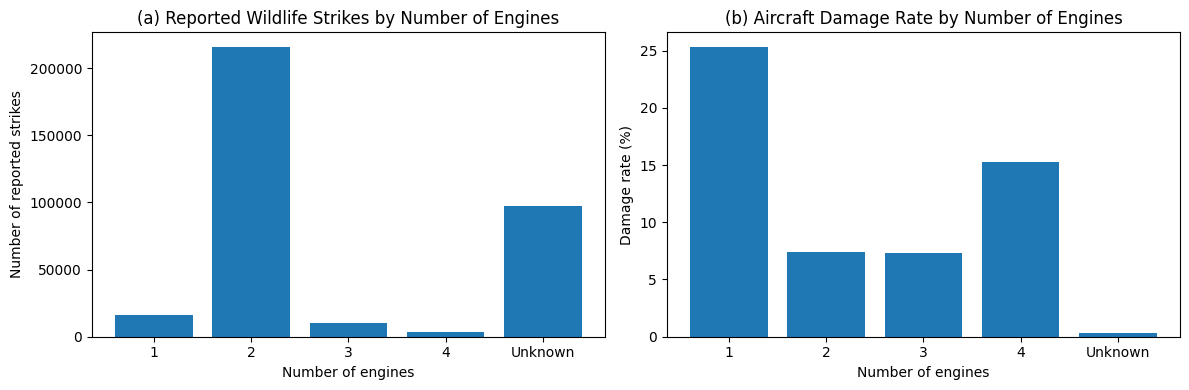

In [209]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Panel (a): reported strike counts
axes[0].bar(
    num_engines_summary["NUM_ENGS_DISPLAY"],
    num_engines_summary["Reported_Strikes"]
)

axes[0].set_title(
    "(a) Reported Wildlife Strikes by Number of Engines"
)
axes[0].set_xlabel("Number of engines")
axes[0].set_ylabel("Number of reported strikes")

# Panel (b): damage rate
axes[1].bar(
    num_engines_summary["NUM_ENGS_DISPLAY"],
    num_engines_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "(b) Aircraft Damage Rate by Number of Engines"
)
axes[1].set_xlabel("Number of engines")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Aircraft with two engines accounted for the largest number of reported wildlife strikes, with 215,899 records. Single-engine aircraft represented a much smaller share of the dataset but had the highest damage rate at 25.33%.

Four-engine aircraft had the second-highest damage rate at 15.23%, while two- and three-engine aircraft had similar rates of approximately 7.4%. The `Unknown` category had a very low damage rate of 0.34% and should be interpreted separately because the number of engines was unavailable for these records.

### 9.5 Engine Position

The `ENG_1_POS` to `ENG_4_POS` variables record the position codes reported for individual aircraft engines. Engine-position information is summarized as a supplement to the number-of-engines analysis.

`Not Applicable` generally indicates that the corresponding engine number does not exist on the aircraft, while `Unknown` indicates that engine-position information was unavailable. Position codes are retained in their original form because their interpretation requires the official source-data mapping.

In [210]:
engine_position_columns = [
    "ENG_1_POS",
    "ENG_2_POS",
    "ENG_3_POS",
    "ENG_4_POS"
]

engine_position_summaries = []

for engine_number, column in enumerate(
    engine_position_columns,
    start=1
):
    position_summary = (
        analysis_df[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace("", "Unknown")
        .value_counts()
        .rename_axis("Position_Code")
        .reset_index(name="Reported_Records")
    )

    position_summary["Engine"] = (
        f"Engine {engine_number}"
    )

    engine_position_summaries.append(
        position_summary
    )

engine_position_summary = pd.concat(
    engine_position_summaries,
    ignore_index=True
)

engine_position_pivot = (
    engine_position_summary
    .pivot_table(
        index="Position_Code",
        columns="Engine",
        values="Reported_Records",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

engine_order = [
    "Position_Code",
    "Engine 1",
    "Engine 2",
    "Engine 3",
    "Engine 4"
]

engine_position_pivot = (
    engine_position_pivot[
        engine_order
    ]
)

display(engine_position_pivot)

Engine,Position_Code,Engine 1,Engine 2,Engine 3,Engine 4
0,1,144282,139931,6897,2231
1,2,62,55,0,0
2,3,241,241,5,5
3,4,17619,17604,1056,1371
4,5,64714,58983,5692,17
5,6,5154,12587,1,0
6,7,13864,1,0,0
7,Not Applicable,0,16410,232309,242336
8,Unknown,97634,97758,97610,97610


#### Observation

Engine-position information was most commonly available for Engines 1 and 2. Position code `1` was the most frequently reported code for both engines, followed by code `5`.

For Engines 3 and 4, `Not Applicable` dominated the records, which is consistent with the fact that most aircraft in the dataset did not have three or four engines. Unknown position information was also common across all engine variables, with approximately 97,000 records in each column.

The position codes are retained in their original form because descriptive labels require confirmation from the official data dictionary.

## 10. Flight Characteristics

This section summarizes reported strike counts and aircraft damage rates by phase of flight, warning status, height, speed, and distance from the airport.

### 10.1 Phase of Flight

Reported strike counts and aircraft damage rates are summarized by phase of flight. Records with unavailable information are retained as `Unknown` and interpreted separately.

In [211]:
analysis_df["PHASE_OF_FLIGHT"].value_counts(dropna=False)

PHASE_OF_FLIGHT
Unknown         135039
Approach         88572
Landing Roll     37716
Take-off Run     34652
Climb            30661
En Route          6464
Departure         3988
Descent           2965
Local             1514
Arrival           1083
Taxi               801
Parked             115
Name: count, dtype: int64

In [212]:
phase_order = [
    "Parked",
    "Taxi",
    "Take-off Run",
    "Departure",
    "Climb",
    "En Route",
    "Descent",
    "Approach",
    "Arrival",
    "Landing Roll",
    "Local",
    "Unknown"
]

phase_summary = (
    analysis_df
    .groupby("PHASE_OF_FLIGHT")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(phase_order)
    .reset_index()
)

phase_summary["Damage_Rate_Pct"] = (
    phase_summary["Damage_Rate"] * 100
)

display(phase_summary)

,PHASE_OF_FLIGHT,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Parked,115,4,0.034783,3.478261
1,Taxi,801,41,0.051186,5.118602
2,Take-off Run,34652,2564,0.073993,7.399284
3,Departure,3988,127,0.031846,3.184554
4,Climb,30661,4433,0.144581,14.458106
5,En Route,6464,1864,0.288366,28.836634
6,Descent,2965,423,0.142664,14.266442
7,Approach,88572,7519,0.084891,8.489139
8,Arrival,1083,49,0.045245,4.524469
9,Landing Roll,37716,2085,0.055282,5.528158


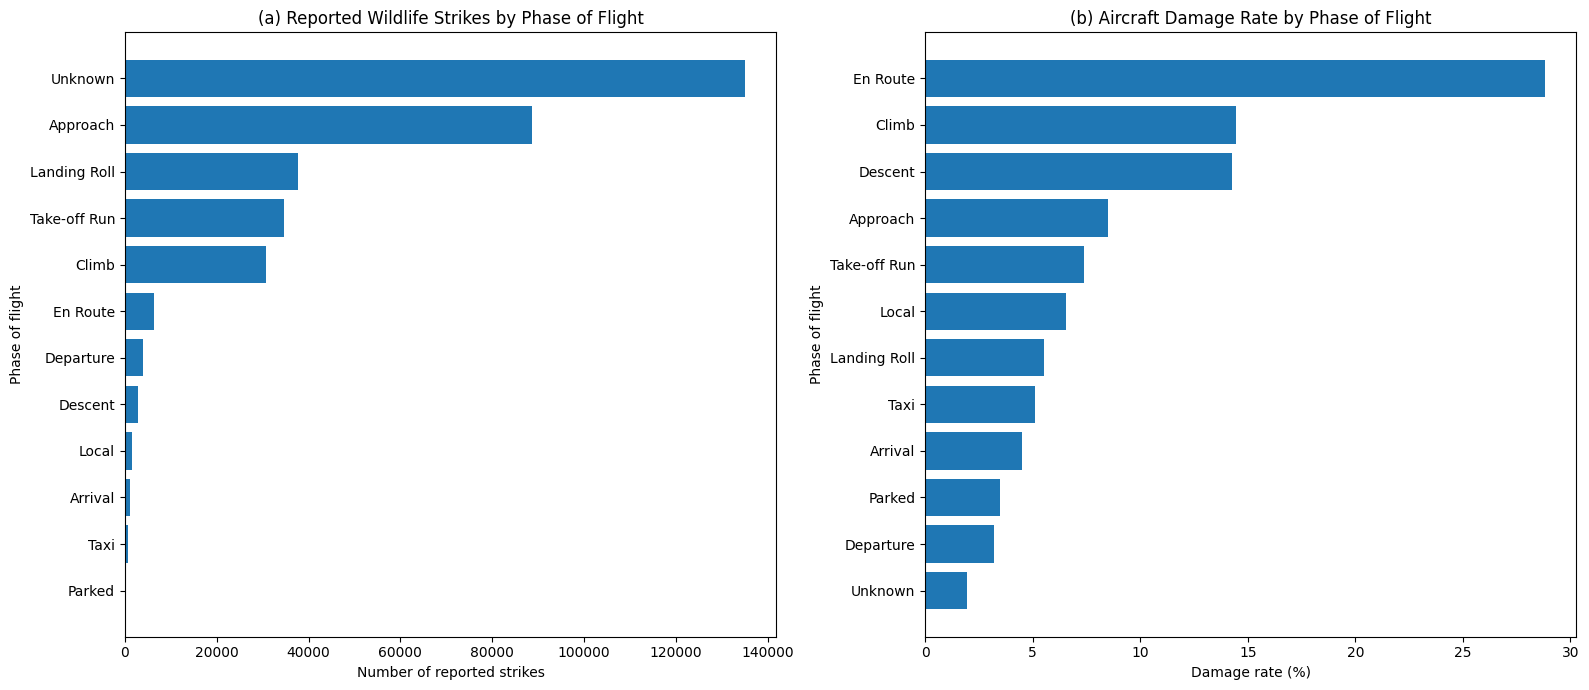

In [213]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

# Panel (a): reported strike counts
count_order = phase_summary.sort_values(
    "Reported_Strikes",
    ascending=True
)

axes[0].barh(
    count_order["PHASE_OF_FLIGHT"],
    count_order["Reported_Strikes"]
)

axes[0].set_title(
    "(a) Reported Wildlife Strikes by Phase of Flight"
)
axes[0].set_xlabel("Number of reported strikes")
axes[0].set_ylabel("Phase of flight")

# Panel (b): damage rate
rate_order = phase_summary.sort_values(
    "Damage_Rate_Pct",
    ascending=True
)

axes[1].barh(
    rate_order["PHASE_OF_FLIGHT"],
    rate_order["Damage_Rate_Pct"]
)

axes[1].set_title(
    "(b) Aircraft Damage Rate by Phase of Flight"
)
axes[1].set_xlabel("Damage rate (%)")
axes[1].set_ylabel("Phase of flight")

plt.tight_layout()
plt.show()

#### Observation

Approach was the most frequently reported known phase of flight, with 88,572 records, followed by landing roll, take-off run, and climb. The `Unknown` category contained the largest overall number of records, with 135,039 observations, and should be interpreted separately because the phase of flight was unavailable.

En route incidents had the highest aircraft damage rate at 28.84%, followed by climb at 14.46% and descent at 14.27%. Approach accounted for a large number of reported strikes but had a lower damage rate of 8.49%. These results show that phases with the highest reporting volumes did not necessarily have the highest proportions of damaging incidents.

### 10.2 Warning Status

Reported strike counts and aircraft damage rates are summarized by whether the flight crew was warned about wildlife activity before the incident.

In [214]:
analysis_df["WARNED"].value_counts(dropna=False)

WARNED
Unknown    213863
No          67092
Yes         62615
Name: count, dtype: int64

In [215]:
warned_order = [
    "Yes",
    "No",
    "Unknown"
]

warned_summary = (
    analysis_df
    .groupby("WARNED")
    .agg(
        Reported_Strikes=("INDEX_NR", "size"),
        Damage_Records=("INDICATED_DAMAGE", "sum"),
        Damage_Rate=("INDICATED_DAMAGE", "mean")
    )
    .reindex(warned_order)
    .reset_index()
)

warned_summary["Damage_Rate_Pct"] = (
    warned_summary["Damage_Rate"] * 100
)

display(warned_summary)

,WARNED,Reported_Strikes,Damage_Records,Damage_Rate,Damage_Rate_Pct
0,Yes,62615,4363,0.069680,6.967979
1,No,67092,7769,0.115796,11.579622
2,Unknown,213863,9678,0.045253,4.525327


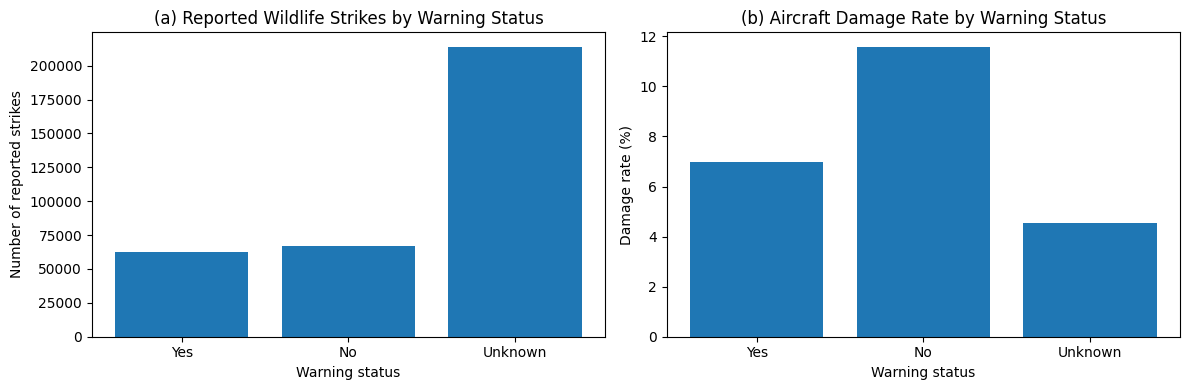

In [216]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Panel (a): reported strike counts
axes[0].bar(
    warned_summary["WARNED"],
    warned_summary["Reported_Strikes"]
)

axes[0].set_title(
    "(a) Reported Wildlife Strikes by Warning Status"
)
axes[0].set_xlabel("Warning status")
axes[0].set_ylabel("Number of reported strikes")

# Panel (b): damage rate
axes[1].bar(
    warned_summary["WARNED"],
    warned_summary["Damage_Rate_Pct"]
)

axes[1].set_title(
    "(b) Aircraft Damage Rate by Warning Status"
)
axes[1].set_xlabel("Warning status")
axes[1].set_ylabel("Damage rate (%)")

plt.tight_layout()
plt.show()

#### Observation

Records with an unknown warning status accounted for the largest share of the dataset, with 213,863 reported strikes. Among records with known warning information, incidents without a prior warning had a higher damage rate than warned incidents, at 11.58% compared with 6.97%.

The `Unknown` category had a lower damage rate of 4.53% and should be interpreted separately because warning-status information was unavailable for these records. These descriptive results indicate an association only and do not establish that warnings directly reduced aircraft damage.

### 10.3 Height, Speed, and Distance

The distributions of reported height, aircraft speed, and distance from the airport are summarized using valid non-missing values. Because these variables are highly skewed, medians and interquartile ranges are emphasized.

In [217]:
numeric_flight_summary = analysis_df[
    ["HEIGHT", "SPEED", "DISTANCE"]
].describe(
    percentiles=[0.25, 0.5, 0.75]
).T

numeric_flight_summary["Missing"] = (
    analysis_df[
        ["HEIGHT", "SPEED", "DISTANCE"]
    ]
    .isna()
    .sum()
)

numeric_flight_summary["Missing_Pct"] = (
    numeric_flight_summary["Missing"]
    / len(analysis_df)
    * 100
)

display(numeric_flight_summary)

,count,mean,std,min,25%,50%,75%,max,Missing,Missing_Pct
HEIGHT,171051.0,881.578225,1855.646158,0.0,0.0,50.0,1000.0,32000.0,172519,50.213639
SPEED,106444.0,143.015839,46.492552,0.0,120.0,140.0,160.0,541.0,237126,69.018250
DISTANCE,227838.0,0.886404,3.709422,0.0,0.0,0.0,0.0,99.0,115732,33.685130


#### Observation

The continuous flight variables contained substantial missingness, particularly `SPEED` (69.02%) and `HEIGHT` (50.21%). `DISTANCE` had lower but still considerable missingness at 33.69%.

All three variables were strongly right-skewed. Median height was 50 feet compared with a mean of 881.58 feet, while the median distance from the airport was 0 despite a maximum of 99. Speed was more concentrated, with a median of 140 knots and an interquartile range of 120-160 knots. These distributions are therefore summarized using medians and interquartile ranges rather than means alone.

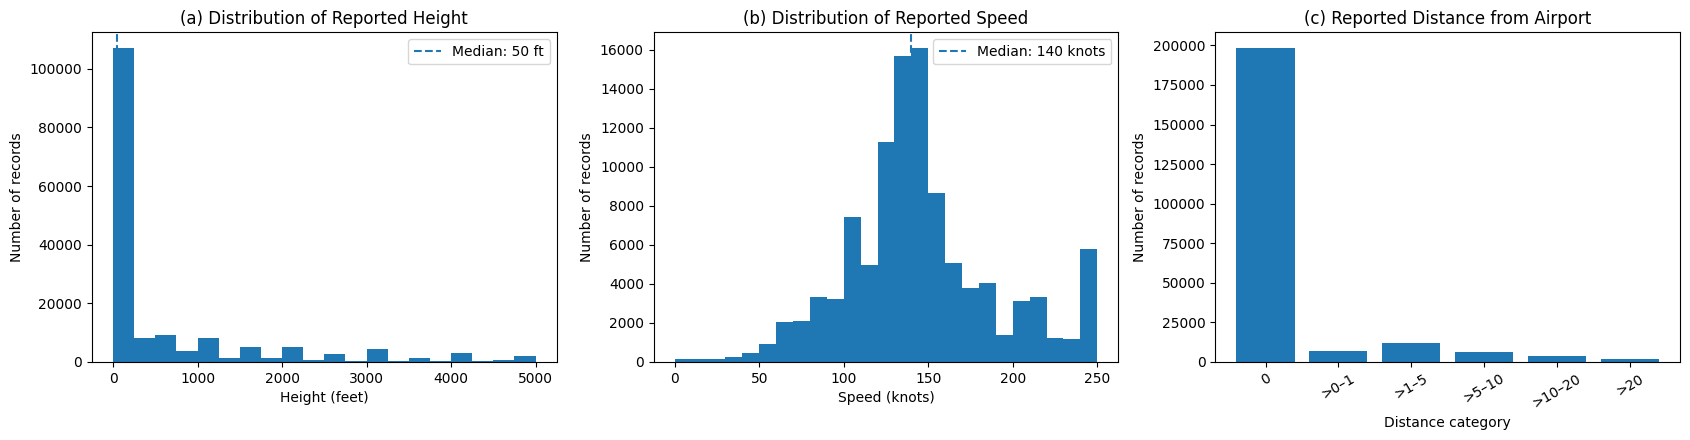

In [218]:
# Create clearer descriptive plots for height, speed, and distance

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5)
)

# Panel (a): Height
height_values = analysis_df["HEIGHT"].dropna()
height_plot = height_values[
    height_values.between(0, 5000)
]

axes[0].hist(
    height_plot,
    bins=np.arange(0, 5250, 250)
)

axes[0].axvline(
    height_values.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {height_values.median():,.0f} ft"
)

axes[0].set_title(
    "(a) Distribution of Reported Height"
)
axes[0].set_xlabel("Height (feet)")
axes[0].set_ylabel("Number of records")
axes[0].legend()


# Panel (b): Speed
speed_values = analysis_df["SPEED"].dropna()
speed_plot = speed_values[
    speed_values.between(0, 250)
]

axes[1].hist(
    speed_plot,
    bins=np.arange(0, 260, 10)
)

axes[1].axvline(
    speed_values.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {speed_values.median():,.0f} knots"
)

axes[1].set_title(
    "(b) Distribution of Reported Speed"
)
axes[1].set_xlabel("Speed (knots)")
axes[1].set_ylabel("Number of records")
axes[1].legend()


# Panel (c): Distance grouped into intervals
distance_values = analysis_df["DISTANCE"].dropna()

distance_groups = pd.cut(
    distance_values,
    bins=[-0.001, 0, 1, 5, 10, 20, np.inf],
    labels=[
        "0",
        ">0–1",
        ">1–5",
        ">5–10",
        ">10–20",
        ">20"
    ]
)

distance_counts = (
    distance_groups
    .value_counts()
    .sort_index()
)

axes[2].bar(
    distance_counts.index.astype(str),
    distance_counts.values
)

axes[2].set_title(
    "(c) Reported Distance from Airport"
)
axes[2].set_xlabel("Distance category")
axes[2].set_ylabel("Number of records")
axes[2].tick_params(
    axis="x",
    rotation=30
)

plt.tight_layout()
plt.show()

The height and speed plots are restricted to commonly reported ranges for clearer visualization. The distance variable is grouped into intervals because most reported values are concentrated at or near zero. All records remain included in the numerical summary table.

#### Observation

Reported height was strongly concentrated near ground level, with a median of 50 feet. Although some incidents occurred at much higher altitudes, most recorded values were within the lower altitude range.

Reported speed was more concentrated, with a median of 140 knots and most observations falling between approximately 100 and 180 knots. Distance from the airport was highly concentrated at zero, indicating that many reported incidents occurred at or very near the airport. Because these variables contain substantial missingness, the distributions describe only records with available values.

## 11. Damage Outcomes

This section summarizes the distribution of aircraft damage severity and component-level damage among reported wildlife-strike incidents.

### 11.1 Damage Severity

The `DAMAGE_LEVEL` variable records the level of aircraft damage assigned by the database manager. The categories follow the ICAO definitions provided in the source documentation.

| Code | Severity level | Definition |
|---|---|---|
| N | No damage | No aircraft damage was reported. |
| M | Minor | The aircraft can be returned to an airworthy condition through simple repairs or replacements without an extensive inspection. |
| M? | Undetermined level | Aircraft damage was confirmed, but the available information was insufficient to determine its severity. |
| S | Substantial | The damage adversely affected structural strength, performance, or flight characteristics and would normally require major repair or component replacement. |
| D | Destroyed | The damage made it inadvisable to restore the aircraft to an airworthy condition. |

Damage severity is summarized for all reported incidents and separately among incidents with confirmed aircraft damage.

In [219]:
# Define severity labels based on the source documentation
severity_labels = {
    "N": "No Damage",
    "M": "Minor",
    "M?": "Undetermined",
    "S": "Substantial",
    "D": "Destroyed"
}

severity_order = [
    "N",
    "M",
    "M?",
    "S",
    "D"
]

In [220]:
severity_summary = (
    analysis_df
    .groupby("DAMAGE_LEVEL")
    .size()
    .reindex(severity_order)
    .fillna(0)
    .astype(int)
    .rename("Reported_Strikes")
    .reset_index()
)

severity_summary["Percentage"] = (
    severity_summary["Reported_Strikes"]
    / severity_summary["Reported_Strikes"].sum()
    * 100
)

severity_summary["Severity"] = (
    severity_summary["DAMAGE_LEVEL"]
    .map(severity_labels)
)

severity_summary = severity_summary[
    [
        "DAMAGE_LEVEL",
        "Severity",
        "Reported_Strikes",
        "Percentage"
    ]
]

display(severity_summary)

,DAMAGE_LEVEL,Severity,Reported_Strikes,Percentage
0,N,No Damage,321760,93.651949
1,M,Minor,8762,2.550281
2,M?,Undetermined,8573,2.495270
3,S,Substantial,4386,1.276596
4,D,Destroyed,89,0.025904


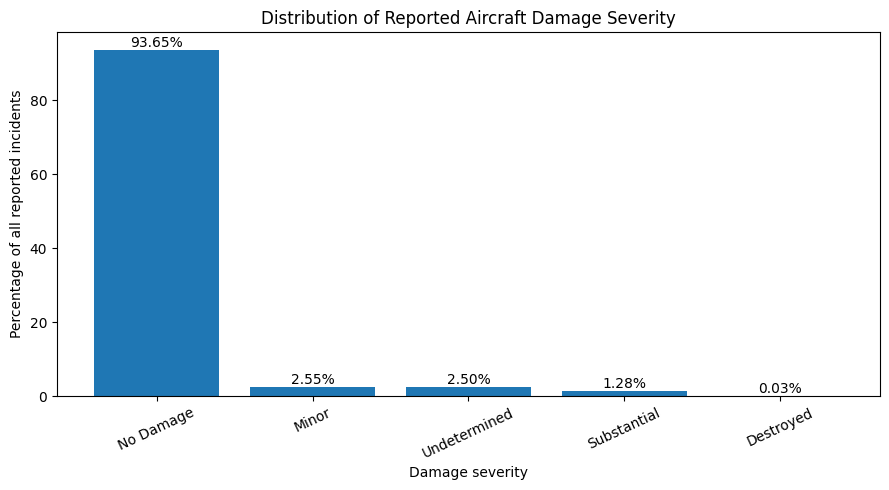

In [221]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    severity_summary["Severity"],
    severity_summary["Percentage"]
)

ax.set_title(
    "Distribution of Reported Aircraft Damage Severity"
)
ax.set_xlabel("Damage severity")
ax.set_ylabel("Percentage of all reported incidents")
ax.tick_params(
    axis="x",
    rotation=25
)

for index, value in enumerate(
    severity_summary["Percentage"]
):
    ax.text(
        index,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Observation

No-damage incidents accounted for 93.65% of all reported records. Among the remaining incidents, minor damage represented 2.55% of the full dataset, undetermined damage severity represented 2.50%, substantial damage represented 1.28%, and destroyed aircraft represented only 0.03%.

The relatively large `Undetermined` category shows that severity details were unavailable for many confirmed damage incidents. For this reason, `M?` should remain separate from the `Minor` category in later severity analysis.

### 11.2 Severity Among Damaged Incidents

Damage severity is examined only among incidents where aircraft damage was confirmed. The `Undetermined` category remains separate because the extent of damage was not available.

In [222]:
damaged_df = analysis_df[
    analysis_df["INDICATED_DAMAGE"] == 1
].copy()

damaged_severity_order = [
    "M",
    "M?",
    "S",
    "D"
]

damaged_severity_summary = (
    damaged_df
    .groupby("DAMAGE_LEVEL")
    .size()
    .reindex(damaged_severity_order)
    .fillna(0)
    .astype(int)
    .rename("Damage_Records")
    .reset_index()
)

damaged_severity_summary["Percentage"] = (
    damaged_severity_summary["Damage_Records"]
    / damaged_severity_summary["Damage_Records"].sum()
    * 100
)

damaged_severity_summary["Severity"] = (
    damaged_severity_summary["DAMAGE_LEVEL"]
    .map(severity_labels)
)

damaged_severity_summary = damaged_severity_summary[
    [
        "DAMAGE_LEVEL",
        "Severity",
        "Damage_Records",
        "Percentage"
    ]
]

display(damaged_severity_summary)

,DAMAGE_LEVEL,Severity,Damage_Records,Percentage
0,M,Minor,8762,40.174232
1,M?,Undetermined,8573,39.307657
2,S,Substantial,4386,20.110041
3,D,Destroyed,89,0.408070


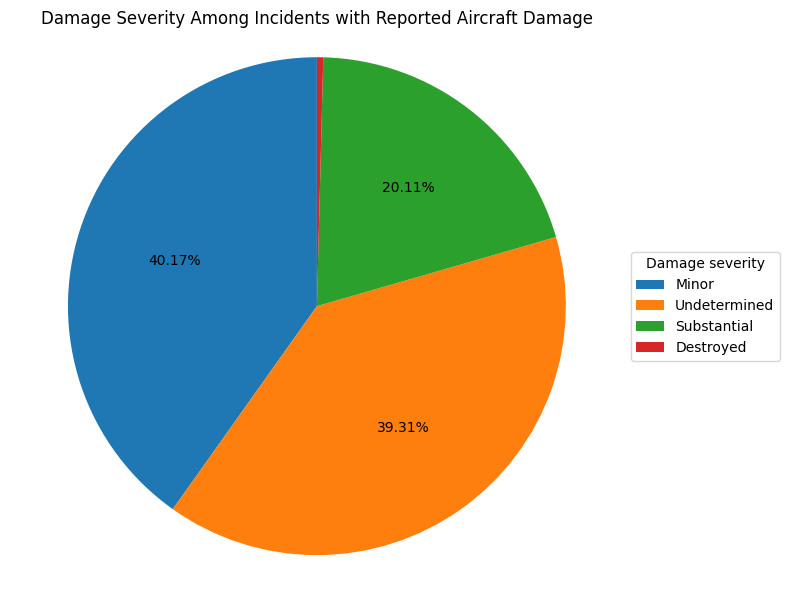

In [223]:
fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    damaged_severity_summary["Percentage"],
    labels=None,
    autopct=lambda pct: f"{pct:.2f}%" if pct >= 1 else "",
    startangle=90
)

ax.set_title(
    "Damage Severity Among Incidents with Reported Aircraft Damage"
)

ax.legend(
    wedges,
    damaged_severity_summary["Severity"],
    title="Damage severity",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

ax.axis("equal")

plt.tight_layout()
plt.show()

#### Observation

Among incidents with confirmed aircraft damage, minor damage accounted for 40.17% of records, while 39.31% had an undetermined severity level. Substantial damage represented 20.11%, and destroyed aircraft accounted for only 0.41%.

The large proportion of undetermined severity indicates that the extent of damage was unavailable for many damaged incidents. Therefore, this category should remain separate from minor damage in later analyses.

### 11.3 Damaged Aircraft Components

The `DAM_*` variables are binary indicators showing whether a specific aircraft component was reported as damaged.

The component categories include the radome, windshield, nose, engines, propeller, wing or rotor, fuselage, landing gear, tail, lights, and other aircraft parts. Multiple components may be damaged in the same incident; therefore, component counts are not mutually exclusive and should not be summed as separate incidents.

#### Component Variable Definitions

- `STR_*`: indicates that the component was struck.
- `DAM_*`: indicates that the component was damaged.
- `ING_*`: indicates that wildlife was ingested into an engine.
- `INGESTED_OTHER`: indicates ingestion at a location other than an engine.
- `OTHER_SPECIFY`: provides additional free-text information when the affected component is recorded as `Other`.

The current subsection focuses only on the `DAM_*` variables.

In [224]:
# Mapping component-damage variables to readable labels
component_damage_labels = {
    "DAM_RAD": "Radome",
    "DAM_WINDSHLD": "Windshield",
    "DAM_NOSE": "Nose",
    "DAM_ENG1": "Engine 1",
    "DAM_ENG2": "Engine 2",
    "DAM_ENG3": "Engine 3",
    "DAM_ENG4": "Engine 4",
    "DAM_PROP": "Propeller",
    "DAM_WING_ROT": "Wing or Rotor",
    "DAM_FUSE": "Fuselage",
    "DAM_LG": "Landing Gear",
    "DAM_TAIL": "Tail",
    "DAM_LGHTS": "Lights",
    "DAM_OTHER": "Other Components"
}

In [225]:
component_columns = list(component_damage_labels.keys())

component_summary = pd.DataFrame({
    "Component_Variable": component_columns,
    "Component": [
        component_damage_labels[column]
        for column in component_columns
    ],
    "Damage_Records": [
        pd.to_numeric(
            analysis_df[column],
            errors="coerce"
        ).fillna(0).sum()
        for column in component_columns
    ]
})

component_summary["Percentage_of_All_Records"] = (
    component_summary["Damage_Records"]
    / len(analysis_df)
    * 100
)

component_summary["Percentage_of_Damaged_Records"] = (
    component_summary["Damage_Records"]
    / len(damaged_df)
    * 100
)

component_summary = (
    component_summary
    .sort_values(
        "Damage_Records",
        ascending=False
    )
    .reset_index(drop=True)
)

display(component_summary)

,Component_Variable,Component,Damage_Records,Percentage_of_All_Records,Percentage_of_Damaged_Records
0,DAM_WING_ROT,Wing or Rotor,6611,1.924208,30.311784
1,DAM_ENG1,Engine 1,3176,0.924411,14.562127
2,DAM_ENG2,Engine 2,2710,0.788777,12.425493
3,DAM_OTHER,Other Components,2561,0.745409,11.742320
4,DAM_RAD,Radome,2183,0.635387,10.009170
5,DAM_NOSE,Nose,1851,0.538755,8.486933
6,DAM_WINDSHLD,Windshield,1529,0.445033,7.010546
7,DAM_LG,Landing Gear,1352,0.393515,6.198991
8,DAM_FUSE,Fuselage,1249,0.363536,5.726731
9,DAM_TAIL,Tail,1091,0.317548,5.002293


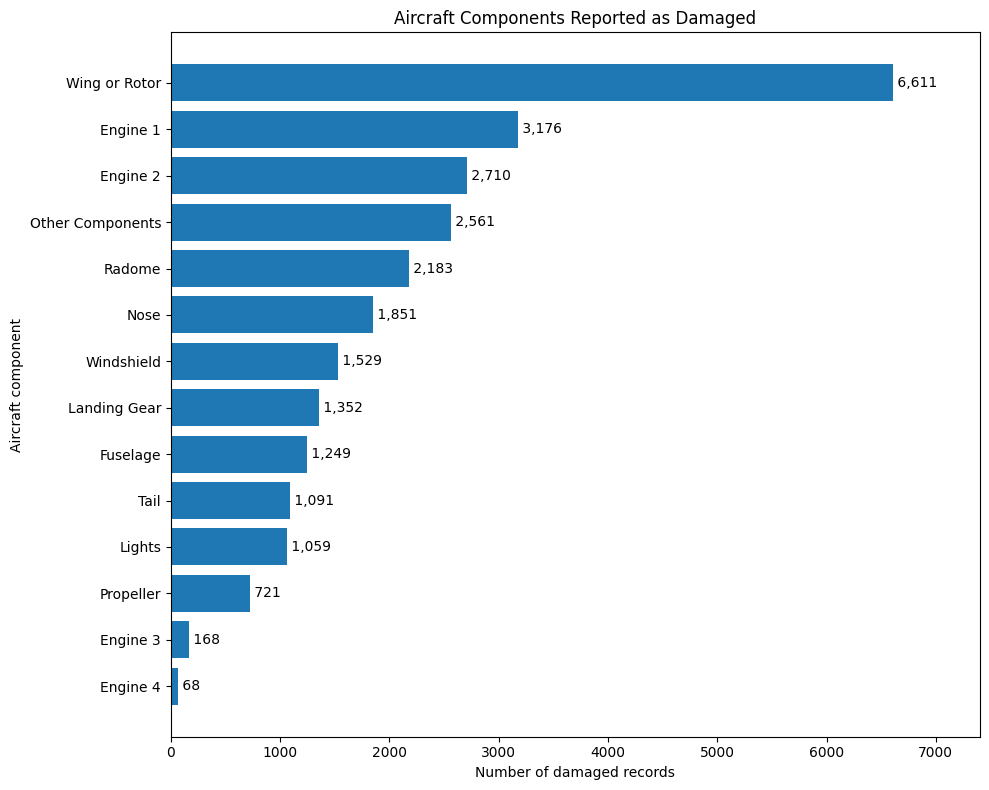

In [226]:
plot_components = (
    component_summary
    .sort_values(
        "Damage_Records",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    plot_components["Component"],
    plot_components["Damage_Records"]
)

ax.set_title(
    "Aircraft Components Reported as Damaged"
)
ax.set_xlabel("Number of damaged records")
ax.set_ylabel("Aircraft component")

# Add count labels to each bar
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value):,}",
        ha="left",
        va="center"
    )

# Add space for the count labels
ax.set_xlim(
    0,
    plot_components["Damage_Records"].max() * 1.12
)

plt.tight_layout()
plt.show()

#### Observation

Wing or rotor damage was the most frequently reported component outcome, appearing in 6,611 records and representing 30.31% of damaged incidents. Engine 1 and Engine 2 damage followed, accounting for 14.56% and 12.43% of damaged incidents, respectively.

Damage was also frequently reported for other components, the radome, nose, and windshield. Because more than one component may be damaged in the same incident, the percentages are not mutually exclusive and should not be added together.

### 11.4 Struck Aircraft Components

The `STR_*` variables indicate whether a specific aircraft component was struck during the incident. Multiple components may be struck in the same incident; therefore, the component counts are not mutually exclusive.

In [227]:
component_strike_labels = {
    "STR_RAD": "Radome",
    "STR_WINDSHLD": "Windshield",
    "STR_NOSE": "Nose",
    "STR_ENG1": "Engine 1",
    "STR_ENG2": "Engine 2",
    "STR_ENG3": "Engine 3",
    "STR_ENG4": "Engine 4",
    "STR_PROP": "Propeller",
    "STR_WING_ROT": "Wing or Rotor",
    "STR_FUSE": "Fuselage",
    "STR_LG": "Landing Gear",
    "STR_TAIL": "Tail",
    "STR_LGHTS": "Lights",
    "STR_OTHER": "Other Components"
}

In [228]:
strike_component_columns = list(component_strike_labels.keys())

strike_component_summary = pd.DataFrame({
    "Component_Variable": strike_component_columns,
    "Component": [
        component_strike_labels[column]
        for column in strike_component_columns
    ],
    "Strike_Records": [
        pd.to_numeric(
            analysis_df[column],
            errors="coerce"
        ).fillna(0).sum()
        for column in strike_component_columns
    ]
})

strike_component_summary["Percentage_of_All_Records"] = (
    strike_component_summary["Strike_Records"]
    / len(analysis_df)
    * 100
)

strike_component_summary = (
    strike_component_summary
    .sort_values(
        "Strike_Records",
        ascending=False
    )
    .reset_index(drop=True)
)

display(strike_component_summary)

,Component_Variable,Component,Strike_Records,Percentage_of_All_Records
0,STR_OTHER,Other Components,47777,13.906045
1,STR_WING_ROT,Wing or Rotor,42401,12.341299
2,STR_WINDSHLD,Windshield,40548,11.801962
3,STR_NOSE,Nose,39619,11.531566
4,STR_RAD,Radome,30272,8.811014
5,STR_FUSE,Fuselage,29841,8.685566
6,STR_ENG1,Engine 1,15764,4.588294
7,STR_LG,Landing Gear,14352,4.177315
8,STR_ENG2,Engine 2,13583,3.953488
9,STR_PROP,Propeller,5336,1.553104


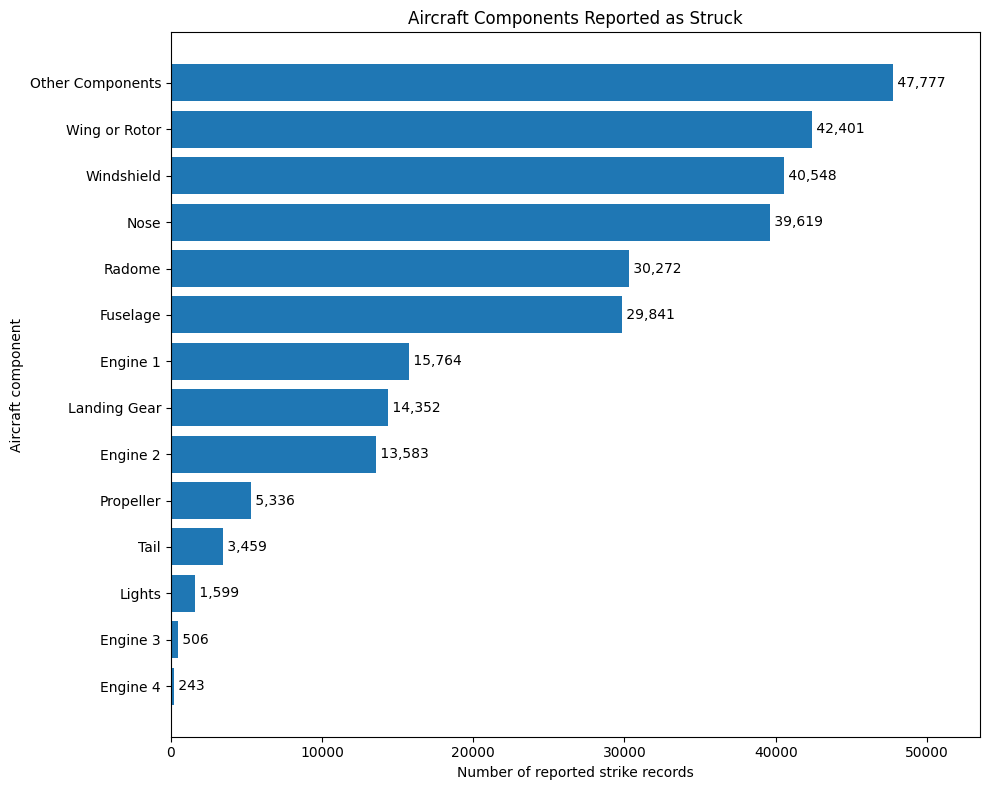

In [229]:
plot_struck_components = (
    strike_component_summary
    .sort_values(
        "Strike_Records",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    plot_struck_components["Component"],
    plot_struck_components["Strike_Records"]
)

ax.set_title(
    "Aircraft Components Reported as Struck"
)
ax.set_xlabel("Number of reported strike records")
ax.set_ylabel("Aircraft component")

# Add count labels to the bars
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value):,}",
        va="center",
        ha="left"
    )

# Add space for value labels
ax.set_xlim(
    0,
    plot_struck_components["Strike_Records"].max() * 1.12
)

plt.tight_layout()
plt.show()

#### Observation

The full component ranking shows that `Other Components` was the most frequently reported struck category, followed by wing or rotor, windshield, and nose. Radome and fuselage also recorded relatively high strike counts.

Engine 3, Engine 4, lights, and tail were struck much less frequently than the leading component categories. Among the specifically identified components, wing or rotor had the highest strike count. Because multiple components may be struck in one incident, the component counts are not mutually exclusive.

### 11.5 Wildlife Ingestion

The ingestion variables indicate whether wildlife was ingested into an aircraft engine or another aircraft location.

- `ING_ENG1` to `ING_ENG4` indicate ingestion into Engines 1-4.
- `INGESTED_OTHER` indicates ingestion at a location other than an engine.

Multiple ingestion indicators may be recorded for the same incident; therefore, the counts are not necessarily mutually exclusive.

In [230]:
ingestion_labels = {
    "ING_ENG1": "Engine 1",
    "ING_ENG2": "Engine 2",
    "ING_ENG3": "Engine 3",
    "ING_ENG4": "Engine 4",
    "INGESTED_OTHER": "Other / Legacy Ingestion"
}

In [231]:
ingestion_columns = list(ingestion_labels.keys())

ingestion_summary = pd.DataFrame({
    "Ingestion_Variable": ingestion_columns,
    "Ingestion_Location": [
        ingestion_labels[column]
        for column in ingestion_columns
    ],
    "Ingestion_Records": [
        pd.to_numeric(
            analysis_df[column],
            errors="coerce"
        ).fillna(0).sum()
        for column in ingestion_columns
    ]
})

ingestion_summary["Percentage_of_All_Records"] = (
    ingestion_summary["Ingestion_Records"]
    / len(analysis_df)
    * 100
)

ingestion_summary["Percentage_of_Damaged_Records"] = (
    ingestion_summary["Ingestion_Records"]
    / len(damaged_df)
    * 100
)

ingestion_summary = (
    ingestion_summary
    .sort_values(
        "Ingestion_Records",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ingestion_summary)

,Ingestion_Variable,Ingestion_Location,Ingestion_Records,Percentage_of_All_Records,Percentage_of_Damaged_Records
0,INGESTED_OTHER,Other / Legacy Ingestion,11268,3.279681,51.664374
1,ING_ENG1,Engine 1,1970,0.573391,9.032554
2,ING_ENG2,Engine 2,1922,0.559420,8.812471
3,ING_ENG3,Engine 3,29,0.008441,0.132967
4,ING_ENG4,Engine 4,10,0.002911,0.045851


#### Observation

`INGESTED_OTHER` contained 11,268 records, substantially more than any individual engine-ingestion indicator. Engine 1 and Engine 2 ingestion were reported in 1,970 and 1,922 records, respectively, while Engine 3 and Engine 4 ingestion were rarely reported.

However, `INGESTED_OTHER` cannot be interpreted exclusively as ingestion outside an engine. According to the source documentation, this variable also contains all ingestion records submitted before March 29, 2021. Therefore, its count combines a legacy reporting category with post-2021 ingestion at non-engine locations.

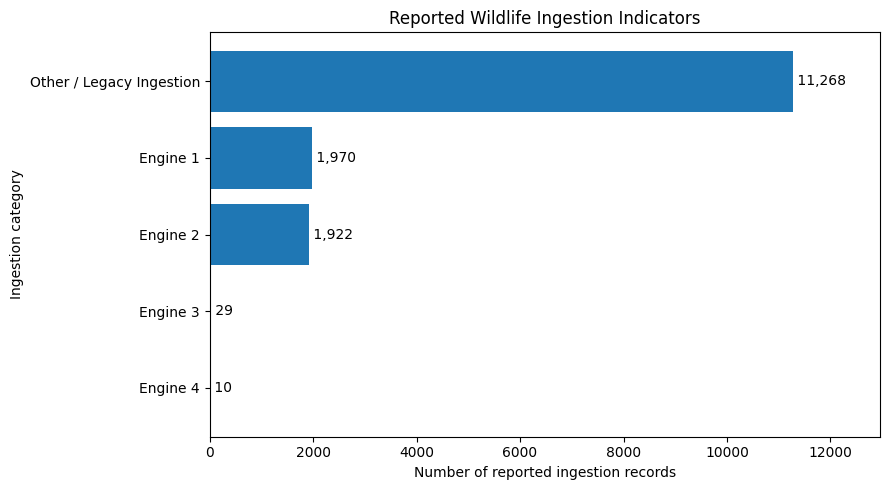

In [232]:
plot_ingestion = (
    ingestion_summary
    .sort_values(
        "Ingestion_Records",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_ingestion["Ingestion_Location"],
    plot_ingestion["Ingestion_Records"]
)

ax.set_title(
    "Reported Wildlife Ingestion Indicators"
)
ax.set_xlabel("Number of reported ingestion records")
ax.set_ylabel("Ingestion category")

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value):,}",
        ha="left",
        va="center"
    )

ax.set_xlim(
    0,
    plot_ingestion["Ingestion_Records"].max() * 1.15
)

plt.tight_layout()
plt.show()

#### Observation

The `Other / Legacy Ingestion` category contained 11,268 records and was substantially larger than the engine-specific ingestion categories. Among the identified engines, Engine 1 and Engine 2 had similar ingestion counts, with 1,970 and 1,922 records, respectively. Ingestion into Engine 3 and Engine 4 was rarely reported.

The `Other / Legacy Ingestion` category requires careful interpretation because it includes all ingestion records submitted before March 29, 2021, as well as post-2021 ingestion at locations other than an engine. Therefore, the chart does not indicate that ingestion outside an engine occurred more frequently than engine ingestion.

### 11.6 Component Damage Rate Among Reported Strikes

For each aircraft component, the number of reported damage records is compared with the number of reported strike records.

The component damage rate is calculated as:

**Damage records ÷ Strike records × 100**

This measure describes the proportion of reported component strikes that were also recorded as component damage. It does not establish that the strike directly caused the reported damage.

In [233]:
# Match the strike and damage variables for each aircraft component
component_pairs = {
    "Radome": ("STR_RAD", "DAM_RAD"),
    "Windshield": ("STR_WINDSHLD", "DAM_WINDSHLD"),
    "Nose": ("STR_NOSE", "DAM_NOSE"),
    "Engine 1": ("STR_ENG1", "DAM_ENG1"),
    "Engine 2": ("STR_ENG2", "DAM_ENG2"),
    "Engine 3": ("STR_ENG3", "DAM_ENG3"),
    "Engine 4": ("STR_ENG4", "DAM_ENG4"),
    "Propeller": ("STR_PROP", "DAM_PROP"),
    "Wing or Rotor": ("STR_WING_ROT", "DAM_WING_ROT"),
    "Fuselage": ("STR_FUSE", "DAM_FUSE"),
    "Landing Gear": ("STR_LG", "DAM_LG"),
    "Tail": ("STR_TAIL", "DAM_TAIL"),
    "Lights": ("STR_LGHTS", "DAM_LGHTS"),
    "Other Components": ("STR_OTHER", "DAM_OTHER")
}

In [234]:
component_rate_records = []

for component, (strike_column, damage_column) in component_pairs.items():

    strike_records = (
        pd.to_numeric(
            analysis_df[strike_column],
            errors="coerce"
        )
        .fillna(0)
        .sum()
    )

    damage_records = (
        pd.to_numeric(
            analysis_df[damage_column],
            errors="coerce"
        )
        .fillna(0)
        .sum()
    )

    damage_rate = (
        damage_records / strike_records * 100
        if strike_records > 0
        else np.nan
    )

    component_rate_records.append({
        "Component": component,
        "Strike_Records": int(strike_records),
        "Damage_Records": int(damage_records),
        "Damage_Rate_Percent": damage_rate
    })

component_damage_rate_summary = pd.DataFrame(
    component_rate_records
)

component_damage_rate_summary = (
    component_damage_rate_summary
    .sort_values(
        "Damage_Rate_Percent",
        ascending=False
    )
    .reset_index(drop=True)
)

display(component_damage_rate_summary)

,Component,Strike_Records,Damage_Records,Damage_Rate_Percent
0,Lights,1599,1059,66.228893
1,Engine 3,506,168,33.201581
2,Tail,3459,1091,31.540908
3,Engine 4,243,68,27.983539
4,Engine 1,15764,3176,20.147171
5,Engine 2,13583,2710,19.951410
6,Wing or Rotor,42401,6611,15.591613
7,Propeller,5336,721,13.511994
8,Landing Gear,14352,1352,9.420290
9,Radome,30272,2183,7.211284


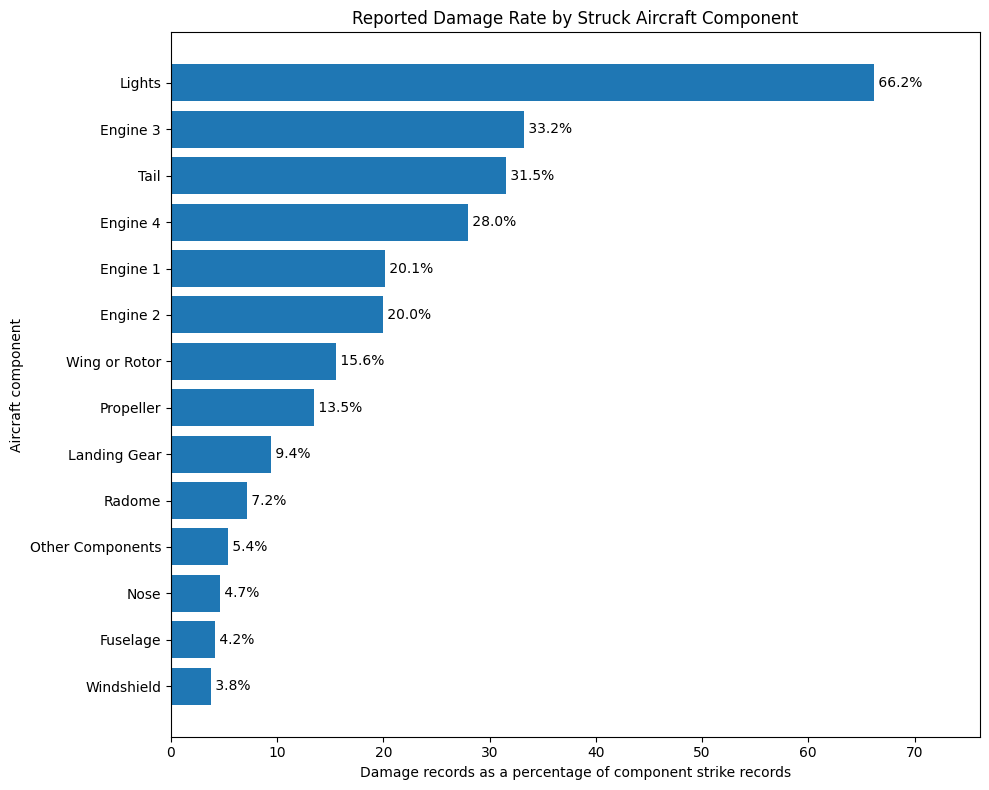

In [235]:
plot_component_rates = (
    component_damage_rate_summary
    .sort_values(
        "Damage_Rate_Percent",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    plot_component_rates["Component"],
    plot_component_rates["Damage_Rate_Percent"]
)

ax.set_title(
    "Reported Damage Rate by Struck Aircraft Component"
)
ax.set_xlabel(
    "Damage records as a percentage of component strike records"
)
ax.set_ylabel("Aircraft component")

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.1f}%",
        ha="left",
        va="center"
    )

ax.set_xlim(
    0,
    plot_component_rates["Damage_Rate_Percent"].max() * 1.15
)

plt.tight_layout()
plt.show()

#### Observation

Lights had the highest reported component damage rate at 66.23%, meaning that approximately two-thirds of incidents in which the lights were reported as struck also recorded light damage. Engine 3, tail, and Engine 4 followed, with damage rates of 33.20%, 31.54%, and 27.98%, respectively.

Engine 1 and Engine 2 had similar damage rates of approximately 20%, while wing or rotor damage was recorded in 15.59% of related component-strike records. Windshield, fuselage, nose, and other components had the lowest reported damage rates, all below 6%.

These percentages describe the relationship between the paired strike and damage indicators for each component. They do not account for differences in strike severity, aircraft characteristics, or reporting practices. Components with relatively small strike counts, particularly Engines 3 and 4, also require careful interpretation.

### 11.7 Reported Impacts

This section summarizes the reported impacts of wildlife-strike incidents, including operational effects on flights, injuries and fatalities, and estimated financial costs.

The impact variables differ in meaning and completeness. Operational effects are categorical, injuries and fatalities are recorded as counts, and financial costs are available only for a subset of incidents. Therefore, each impact category is summarized separately.

In [236]:
# Create summary for operational effects
effect_summary = (
    analysis_df["EFFECT"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace("", "Unknown")
    .value_counts()
    .rename_axis("Effect")
    .reset_index(name="Reported_Records")
)

effect_summary["Percentage_of_All_Records"] = (
    effect_summary["Reported_Records"]
    / len(analysis_df)
    * 100
)

display(effect_summary)

,Effect,Reported_Records,Percentage_of_All_Records
0,Unknown,327838,95.421020
1,Precautionary Landing,9199,2.677475
2,Aborted Take-off,3291,0.957883
3,Other,2118,0.616468
4,"Other, Precautionary Landing",524,0.152516
5,Engine Shutdown,265,0.077131
6,"Engine Shutdown, Precautionary Landing",211,0.061414
7,"Engine Shutdown, Other, Precautionary Landing",60,0.017464
8,"Aborted Take-off, Engine Shutdown",33,0.009605
9,"Engine Shutdown, Other",18,0.005239


#### Observation

Operational-effect information was unavailable for 327,838 records, representing 95.42% of the analysis dataset. Among the recorded effects, precautionary landing was the most common, with 9,199 incidents, followed by aborted take-off with 3,291 incidents and other reported effects with 2,118 incidents.

Engine shutdown was less frequently reported, either alone or in combination with precautionary landing or other effects. Because the `Unknown` category dominates this variable, the operational-effect results describe only a small subset of incidents with available information.

In [237]:
#Create summary for injuries and fatalities
injury_fatality_summary = pd.DataFrame({

    "Impact": [
        "Incidents with Injuries",
        "Incidents with Fatalities",
        "Total Injuries",
        "Total Fatalities"
    ],
    "Value": [
        (analysis_df["NR_INJURIES"].fillna(0) > 0).sum(),
        (analysis_df["NR_FATALITIES"].fillna(0) > 0).sum(),
        analysis_df["NR_INJURIES"].fillna(0).sum(),
        analysis_df["NR_FATALITIES"].fillna(0).sum()
    ]
})

injury_fatality_summary["Value"] = (
    injury_fatality_summary["Value"]
    .astype(int)
)

display(injury_fatality_summary)

,Impact,Value
0,Incidents with Injuries,300
1,Incidents with Fatalities,25
2,Total Injuries,384
3,Total Fatalities,52


#### Observation

Injuries were reported in 300 incidents, involving a total of 384 injured persons. Fatalities were reported in 25 incidents, with a total of 52 deaths.

The difference between the number of affected incidents and the total number of persons shows that some incidents involved more than one injury or fatality. However, injuries and fatalities were rare relative to the overall number of reported wildlife-strike incidents.

In [238]:
# Create summary for inflation-adjusted costs
cost_variables = {
    "COST_REPAIRS_INFL_ADJ": "Repair Costs",
    "COST_OTHER_INFL_ADJ": "Other Costs"
}

cost_summary_records = []

for column, label in cost_variables.items():

    values = pd.to_numeric(
        analysis_df[column],
        errors="coerce"
    )

    positive_values = values[
        values > 0
    ]

    cost_summary_records.append({
        "Cost_Category": label,
        "Records_with_Positive_Cost": positive_values.count(),
        "Total_Cost_USD": positive_values.sum(),
        "Median_Cost_USD": positive_values.median(),
        "Mean_Cost_USD": positive_values.mean(),
        "Maximum_Cost_USD": positive_values.max()
    })

cost_summary = pd.DataFrame(
    cost_summary_records
)

display(cost_summary)

,Cost_Category,Records_with_Positive_Cost,Total_Cost_USD,Median_Cost_USD,Mean_Cost_USD,Maximum_Cost_USD
0,Repair Costs,5395,1.108013e+09,18645.0,205377.810380,53928000.0
1,Other Costs,5507,1.644396e+08,716.0,29860.105502,13737500.0


#### Observation

Positive inflation-adjusted repair costs were available for 5,395 incidents, with a total reported value of approximately USD 1.11 billion. The median repair cost was USD 18,645, while the mean was substantially higher at approximately USD 205,378. The maximum reported repair cost was USD 53.93 million.

Positive inflation-adjusted other costs were available for 5,507 incidents, with a total value of approximately USD 164.44 million. The median other cost was only USD 716, compared with a mean of approximately USD 29,860 and a maximum of USD 13.74 million.

The large differences between the medians and means indicate that both cost distributions were strongly right-skewed and influenced by a small number of extremely costly incidents.

In [239]:
# Prepare operational-effect data
plot_effects = (
    effect_summary
    .sort_values(
        "Reported_Records",
        ascending=True
    )
)

# Prepare positive inflation-adjusted cost values
repair_costs = pd.to_numeric(
    analysis_df["COST_REPAIRS_INFL_ADJ"],
    errors="coerce"
)

repair_costs = repair_costs[
    repair_costs > 0
]

other_costs = pd.to_numeric(
    analysis_df["COST_OTHER_INFL_ADJ"],
    errors="coerce"
)

other_costs = other_costs[
    other_costs > 0
]

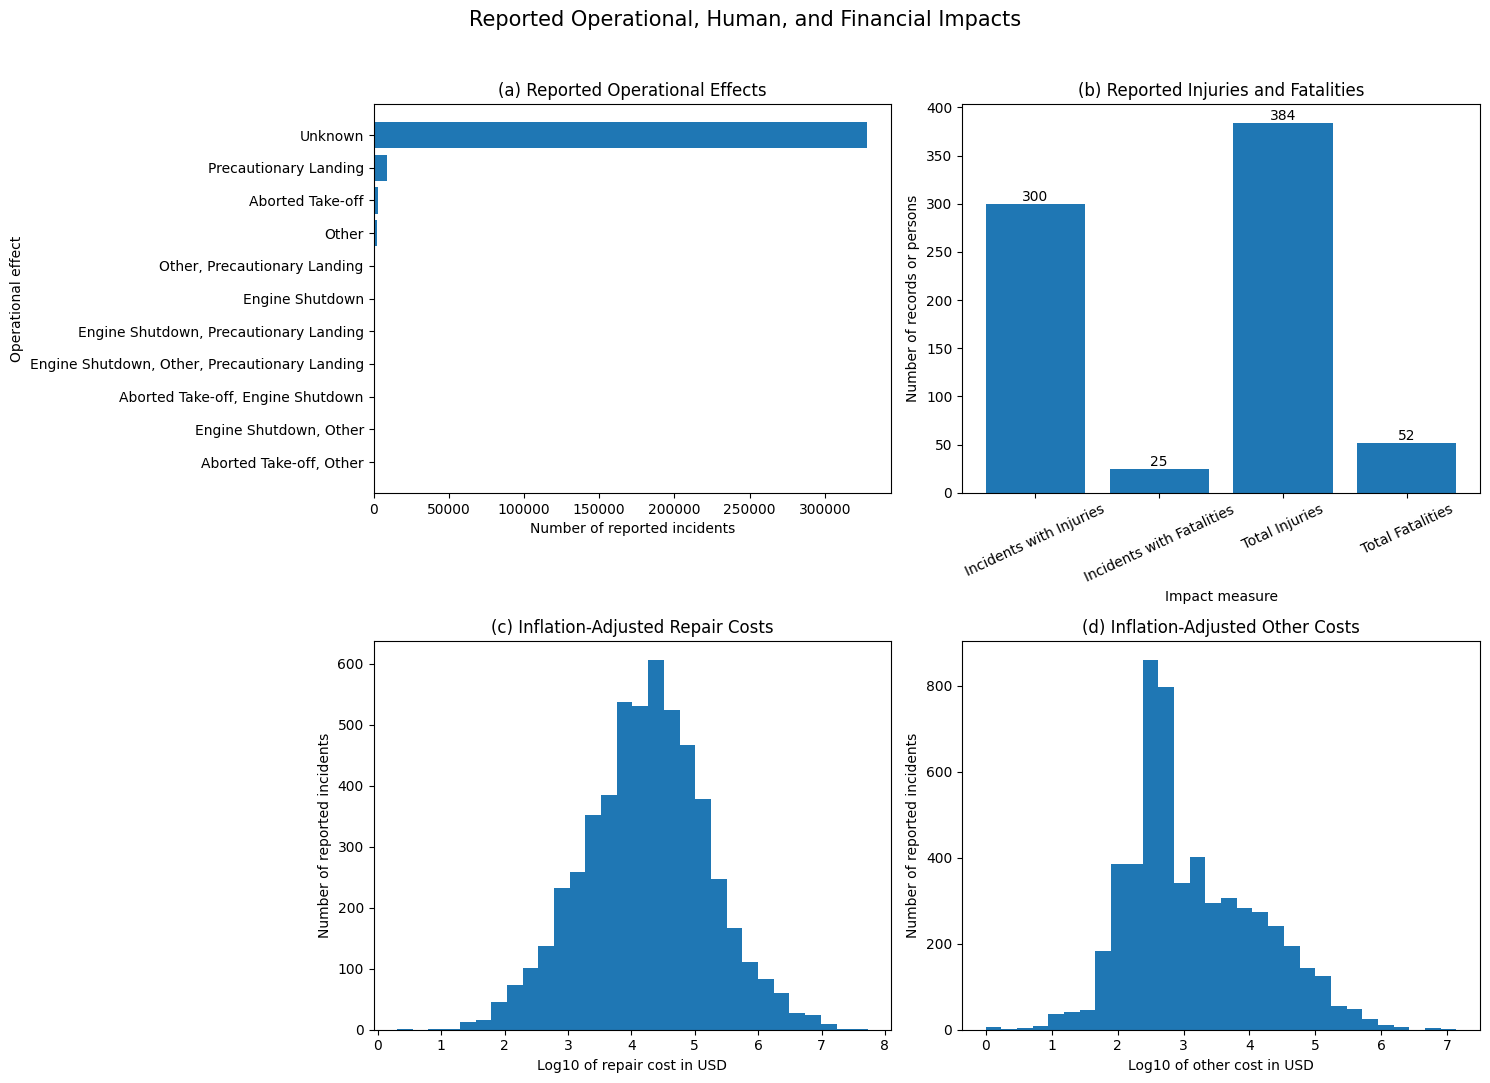

In [240]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11)
)

# --------------------------------------------------
# (a) Operational effects
# --------------------------------------------------
axes[0, 0].barh(
    plot_effects["Effect"],
    plot_effects["Reported_Records"]
)

axes[0, 0].set_title(
    "(a) Reported Operational Effects"
)
axes[0, 0].set_xlabel(
    "Number of reported incidents"
)
axes[0, 0].set_ylabel(
    "Operational effect"
)

# --------------------------------------------------
# (b) Injuries and fatalities
# --------------------------------------------------
impact_plot = injury_fatality_summary.copy()

bars = axes[0, 1].bar(
    impact_plot["Impact"],
    impact_plot["Value"]
)

axes[0, 1].set_title(
    "(b) Reported Injuries and Fatalities"
)
axes[0, 1].set_xlabel(
    "Impact measure"
)
axes[0, 1].set_ylabel(
    "Number of records or persons"
)

axes[0, 1].tick_params(
    axis="x",
    rotation=25
)

for bar in bars:
    value = bar.get_height()

    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

# --------------------------------------------------
# (c) Repair-cost distribution
# --------------------------------------------------
axes[1, 0].hist(
    np.log10(repair_costs),
    bins=30
)

axes[1, 0].set_title(
    "(c) Inflation-Adjusted Repair Costs"
)
axes[1, 0].set_xlabel(
    "Log10 of repair cost in USD"
)
axes[1, 0].set_ylabel(
    "Number of reported incidents"
)

# --------------------------------------------------
# (d) Other-cost distribution
# --------------------------------------------------
axes[1, 1].hist(
    np.log10(other_costs),
    bins=30
)

axes[1, 1].set_title(
    "(d) Inflation-Adjusted Other Costs"
)
axes[1, 1].set_xlabel(
    "Log10 of other cost in USD"
)
axes[1, 1].set_ylabel(
    "Number of reported incidents"
)

plt.suptitle(
    "Reported Operational, Human, and Financial Impacts",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

**Figure note.** Panels (c) and (d) include only records with positive inflation-adjusted costs. A base-10 logarithmic transformation is used because the reported cost distributions are strongly right-skewed and contain a small number of extremely large values.

#### Overall Observation

The combined figure shows that operational, human, and financial impacts were reported for only a small proportion of wildlife-strike incidents. Most records had no available operational-effect information, while precautionary landing was the most common documented flight effect.

Human consequences were uncommon, although some incidents involved multiple injuries or fatalities. The financial distributions were highly right-skewed, with most reported costs concentrated at lower values and a small number of incidents producing very large losses. Repair costs were generally much larger than other reported costs.

Overall, the figure demonstrates that severe operational, human, and financial outcomes were relatively rare, but the incidents that did produce major consequences could involve substantial damage and expense.

## 12. Airport, Seasonal, Wildlife, and Environmental Patterns

This section examines how reported wildlife-strike patterns vary across airports, seasons, wildlife species, and environmental conditions. The analysis focuses on leading airports, frequently reported identified wildlife species or species groups, and the available sky and precipitation information to maintain readable tables and visualizations.

The results describe patterns in reported incidents only. They do not establish that a particular airport, season, wildlife species, or weather condition causes wildlife strikes or aircraft damage. Environmental findings also require careful interpretation because sky and precipitation information is unavailable for a substantial proportion of records.

### 12.1 Top species by airport

In [241]:
unknown_species_categories = [
    "Unknown bird",
    "Unknown bird - small",
    "Unknown bird - medium",
    "Unknown bird - large",
    "Unknown bird or bat",
    "Unknown terrestrial mammal"
]

top_airport_ids = (
    analysis_df.loc[
        ~analysis_df["AIRPORT_ID"].isin(
            ["UNKNOWN", "UNK", "ZZZZ"]
        )
    ]
    .groupby("AIRPORT_ID")
    .size()
    .nlargest(10)
    .index
)

airport_species_df = analysis_df[
    analysis_df["AIRPORT_ID"].isin(top_airport_ids)
    & ~analysis_df["SPECIES"].isin(
        unknown_species_categories
    )
].copy()

In [242]:
# 5 species at each airport:
airport_species_summary = (
    airport_species_df
    .groupby(
        [
            "AIRPORT_ID",
            "AIRPORT",
            "SPECIES"
        ]
    )
    .size()
    .reset_index(name="Reported_Strikes")
)

airport_species_summary["Rank_within_Airport"] = (
    airport_species_summary
    .groupby("AIRPORT_ID")["Reported_Strikes"]
    .rank(
        method="first",
        ascending=False
    )
)

top_airport_species = (
    airport_species_summary[
        airport_species_summary[
            "Rank_within_Airport"
        ] <= 5
    ]
    .sort_values(
        [
            "AIRPORT_ID",
            "Reported_Strikes"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(top_airport_species)

,AIRPORT_ID,AIRPORT,SPECIES,Reported_Strikes,Rank_within_Airport
0,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Killdeer,280,1.0
1,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Mourning dove,275,2.0
2,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,European starling,246,3.0
3,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Barn swallow,165,4.0
4,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Eastern red bat,151,5.0
5,KDEN,DENVER INTL AIRPORT,Horned lark,3505,1.0
6,KDEN,DENVER INTL AIRPORT,Western meadowlark,766,2.0
7,KDEN,DENVER INTL AIRPORT,Mourning dove,722,3.0
8,KDEN,DENVER INTL AIRPORT,Cliff swallow,509,4.0
9,KDEN,DENVER INTL AIRPORT,Rock pigeon,338,5.0


#### Observation

The leading wildlife species varied substantially across airports, indicating clear geographic differences in reported strike composition.

Horned lark strongly dominated reported strikes at Denver International Airport, with 3,505 records, while mourning dove was the leading species at Dallas/Fort Worth and Chicago O’Hare. Gull species were particularly prominent at John F. Kennedy International Airport, where herring gull and laughing gull ranked first and second.

Swallow species appeared frequently at several airports, including Orlando, Detroit, Chicago O’Hare, Salt Lake City, and Sacramento. Killdeer and mourning dove were also common across multiple airports. In contrast, several airports showed more location-specific patterns, such as northern pintail and American barn owl at Sacramento and western cattle egret at Orlando.

These results indicate that the most frequently reported wildlife species were not consistent across airports. However, the counts reflect reported strike records rather than the underlying wildlife population or actual species abundance near each airport.

In [243]:
airport_species_pivot = (
    top_airport_species
    .pivot_table(
        index=["AIRPORT_ID", "AIRPORT"],
        columns="Rank_within_Airport",
        values="SPECIES",
        aggfunc="first"
    )
    .reset_index()
)

airport_species_pivot.columns = [
    "AIRPORT_ID",
    "AIRPORT",
    "Top Species 1",
    "Top Species 2",
    "Top Species 3",
    "Top Species 4",
    "Top Species 5"
]

display(airport_species_pivot)

,AIRPORT_ID,AIRPORT,Top Species 1,Top Species 2,Top Species 3,Top Species 4,Top Species 5
0,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Killdeer,Mourning dove,European starling,Barn swallow,Eastern red bat
1,KDEN,DENVER INTL AIRPORT,Horned lark,Western meadowlark,Mourning dove,Cliff swallow,Rock pigeon
2,KDFW,DALLAS/FORT WORTH INTL ARPT,Mourning dove,Meadowlarks,Rock pigeon,Killdeer,American kestrel
3,KDTW,DETROIT METRO WAYNE COUNTY ARPT,Killdeer,Barn swallow,Horned lark,Mourning dove,European starling
4,KJFK,JOHN F KENNEDY INTL,Herring gull,Laughing gull,American kestrel,Barn swallow,Horned lark
5,KMCO,ORLANDO INTL,Barn swallow,Tree swallow,Killdeer,Mourning dove,Western cattle egret
6,KMEM,MEMPHIS INTL,Eastern meadowlark,Mourning dove,Killdeer,European starling,Barn swallow
7,KORD,CHICAGO O'HARE INTL ARPT,Mourning dove,Barn swallow,American kestrel,Killdeer,European starling
8,KSLC,SALT LAKE CITY INTL,Horned lark,Cliff swallow,American kestrel,Barn swallow,Western meadowlark
9,KSMF,SACRAMENTO INTL,Cliff swallow,Northern pintail,Brazilian free-tailed bat,Western meadowlark,American barn owl


#### Observation

The summarized ranking confirms that wildlife-strike composition differed across the leading airports. Mourning dove, killdeer, barn swallow, American kestrel, European starling, and horned lark appeared repeatedly among the top-five species at several airports.

Some airports also showed more distinctive local patterns. Denver and Salt Lake City were strongly associated with horned lark and western meadowlark, while John F. Kennedy International Airport was characterized by herring gull and laughing gull. Sacramento included northern pintail, Brazilian free-tailed bat, and American barn owl among its leading reported species, whereas Orlando included western cattle egret.

Overall, no single species dominated across all airports. The results suggest that airport location and surrounding habitat may be related to differences in reported wildlife-strike composition, although the dataset does not directly measure habitat conditions or local wildlife abundance.

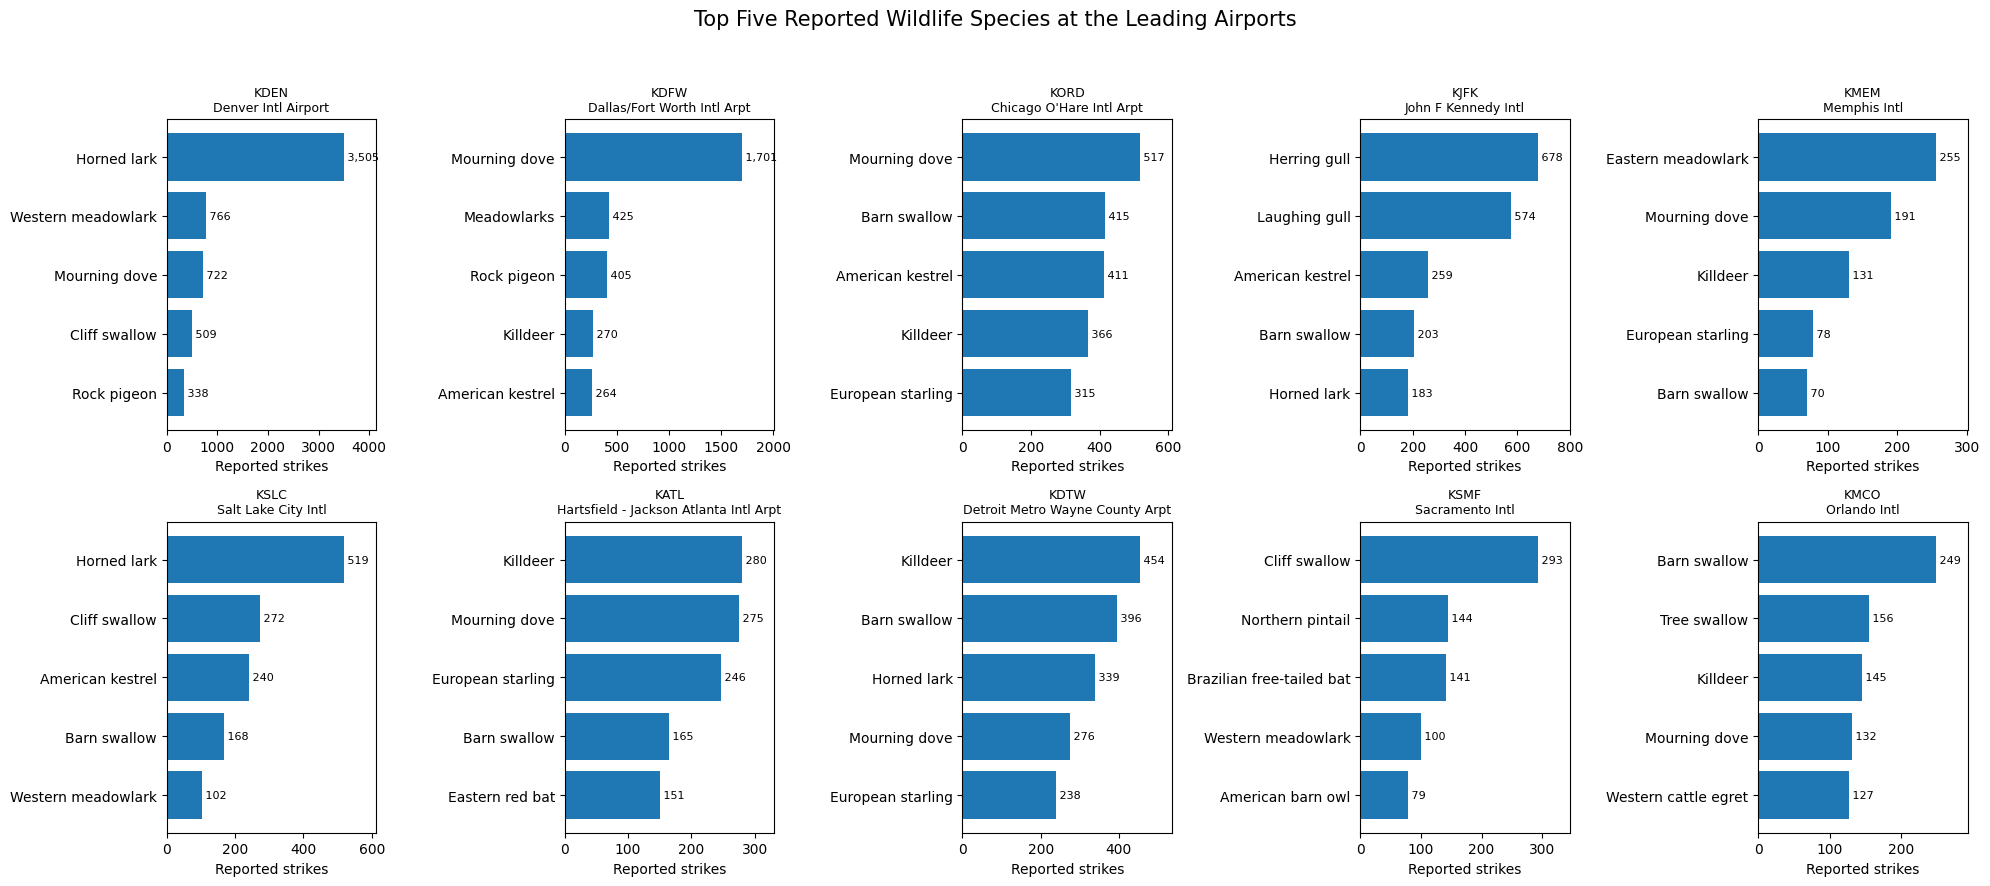

In [244]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(20, 9)
)

axes = axes.flatten()

for ax, airport_id in zip(
    axes,
    top_airport_ids
):
    airport_plot = (
        top_airport_species[
            top_airport_species["AIRPORT_ID"] == airport_id
        ]
        .sort_values(
            "Reported_Strikes",
            ascending=True
        )
    )

    airport_name = (
        airport_plot["AIRPORT"]
        .iloc[0]
        .title()
    )

    bars = ax.barh(
        airport_plot["SPECIES"],
        airport_plot["Reported_Strikes"]
    )

    ax.set_title(
        f"{airport_id}\n{airport_name}",
        fontsize=9
    )

    ax.set_xlabel(
        "Reported strikes"
    )

    for bar in bars:
        value = bar.get_width()

        ax.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f" {int(value):,}",
            ha="left",
            va="center",
            fontsize=8
        )

    ax.set_xlim(
        0,
        airport_plot["Reported_Strikes"].max() * 1.18
    )

plt.suptitle(
    "Top Five Reported Wildlife Species at the Leading Airports",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

#### Observation

The leading reported wildlife species differed considerably across the ten airports, showing clear airport-specific patterns.

Denver International Airport was strongly dominated by horned lark, with 3,505 reported strikes, far more than any other species at that airport. Mourning dove was the most frequently reported species at Dallas/Fort Worth and Chicago O’Hare, while killdeer ranked first at Atlanta and Detroit.

John F. Kennedy International Airport showed a distinctive gull-related pattern, with herring gull and laughing gull occupying the top two positions. Swallow species were prominent at several airports, including Orlando, Salt Lake City, Sacramento, Detroit, and Chicago O’Hare.

Sacramento and Orlando also showed more location-specific wildlife patterns. Sacramento included northern pintail, Brazilian free-tailed bat, and American barn owl among its leading categories, while Orlando included western cattle egret.

Overall, no single wildlife species dominated across all airports. The differences suggest that reported strike composition varies with airport location and surrounding environmental conditions. However, the counts represent reported strike records rather than wildlife abundance around each airport.

### 12.2 Wildlife Species by Season

The seasonal distribution of the ten most frequently reported identified wildlife species or species groups is summarized to examine how reported strike composition varies throughout the year.

In [245]:
# 10 species over dataset and compare to season
top_species = (
    analysis_df.loc[
        ~analysis_df["SPECIES"].isin(
            unknown_species_categories
        ),
        "SPECIES"
    ]
    .value_counts()
    .head(10)
    .index
)

season_species_summary = (
    analysis_df[
        analysis_df["SPECIES"].isin(top_species)
    ]
    .groupby(
        [
            "SEASON",
            "SPECIES"
        ]
    )
    .size()
    .reset_index(name="Reported_Strikes")
)

In [246]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall"
]

season_species_pivot = (
    season_species_summary
    .pivot(
        index="SPECIES",
        columns="SEASON",
        values="Reported_Strikes"
    )
    .fillna(0)
    .reindex(columns=season_order)
)

display(season_species_pivot)

SEASON,Winter,Spring,Summer,Fall
SPECIES,,,,
American kestrel,533,1362,5409,3176
Barn swallow,63,1198,8264,2196
Eastern meadowlark,377,1235,2548,1110
European starling,488,1371,3729,1388
Gulls,1303,2264,1894,2205
Horned lark,1556,1876,3619,2859
Killdeer,806,982,6134,3512
Mourning dove,2004,2289,8005,5611
Red-tailed hawk,964,927,1143,1483


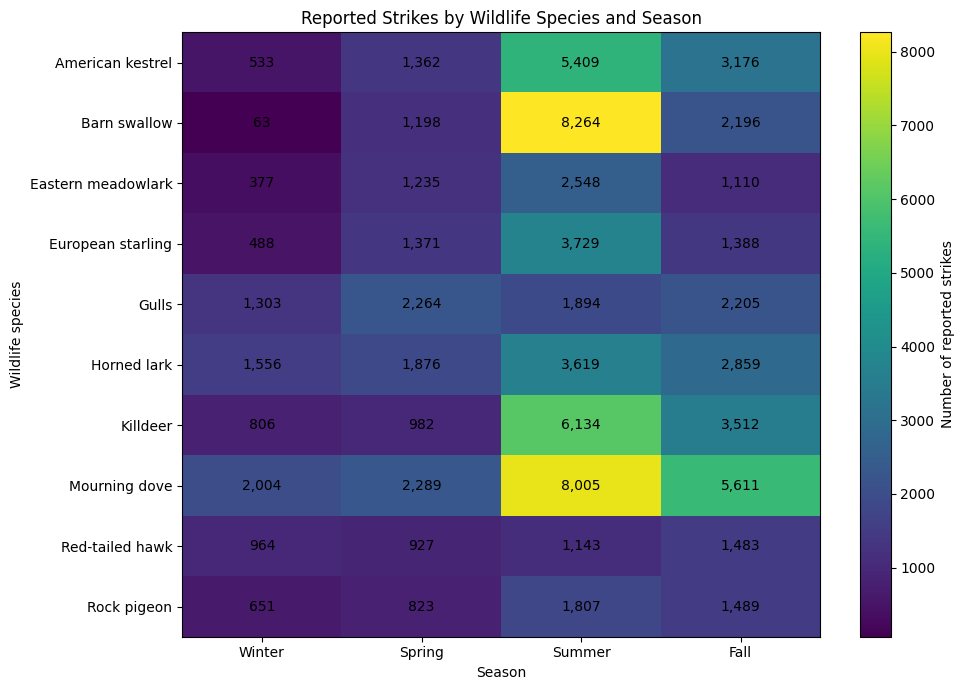

In [247]:
fig, ax = plt.subplots(figsize=(10, 7))

heatmap_data = season_species_pivot.values

image = ax.imshow(
    heatmap_data,
    aspect="auto"
)

ax.set_xticks(
    range(len(season_species_pivot.columns))
)
ax.set_xticklabels(
    season_species_pivot.columns
)

ax.set_yticks(
    range(len(season_species_pivot.index))
)
ax.set_yticklabels(
    season_species_pivot.index
)

ax.set_title(
    "Reported Strikes by Wildlife Species and Season"
)
ax.set_xlabel("Season")
ax.set_ylabel("Wildlife species")

for row in range(
    heatmap_data.shape[0]
):
    for column in range(
        heatmap_data.shape[1]
    ):
        ax.text(
            column,
            row,
            f"{int(heatmap_data[row, column]):,}",
            ha="center",
            va="center"
        )

colorbar = plt.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    "Number of reported strikes"
)

plt.tight_layout()
plt.show()

**Figure note.** The heatmap includes the ten most frequently reported identified wildlife species or species groups. Unidentified wildlife categories are excluded.

#### Observation

The heatmap shows that most of the leading wildlife species were reported most frequently during Summer. Barn swallow had the strongest seasonal concentration, increasing from only 63 reported strikes in Winter to 8,264 in Summer. Mourning dove and killdeer also showed pronounced Summer peaks, with 8,005 and 6,134 reported strikes, respectively.

American kestrel, European starling, eastern meadowlark, horned lark, and rock pigeon also reached their highest reported counts during Summer. In contrast, gulls showed a more balanced seasonal distribution, with their highest count in Spring and similarly high levels in Fall. Red-tailed hawk also displayed a weaker Summer concentration and reached its highest count in Fall.

Overall, the figure indicates that seasonal strike patterns differ substantially across wildlife species. The counts represent reported strike records and do not directly measure seasonal wildlife abundance.

### 12.3 Airport-season patterns

This section indicates which season each airport experiences the highest number of strikes

In [248]:
airport_season_summary = (
    analysis_df[
        analysis_df["AIRPORT_ID"].isin(
            top_airport_ids
        )
    ]
    .groupby(
        [
            "AIRPORT_ID",
            "AIRPORT",
            "SEASON"
        ]
    )
    .agg(
        Reported_Strikes=(
            "INDICATED_DAMAGE",
            "size"
        ),
        Damage_Records=(
            "INDICATED_DAMAGE",
            "sum"
        )
    )
    .reset_index()
)

airport_season_summary[
    "Damage_Rate_Percent"
] = (
    airport_season_summary[
        "Damage_Records"
    ]
    / airport_season_summary[
        "Reported_Strikes"
    ]
    * 100
)

display(
    airport_season_summary
    .sort_values(
        [
            "AIRPORT_ID",
            "Reported_Strikes"
        ],
        ascending=[True, False]
    )
)

,AIRPORT_ID,AIRPORT,SEASON,Reported_Strikes,Damage_Records,Damage_Rate_Percent
0,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Fall,1593,54,3.389831
2,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Summer,1380,33,2.391304
1,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Spring,878,39,4.441913
3,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,Winter,453,20,4.415011
6,KDEN,DENVER INTL AIRPORT,Summer,5649,63,1.115242
4,KDEN,DENVER INTL AIRPORT,Fall,2706,101,3.732446
5,KDEN,DENVER INTL AIRPORT,Spring,2123,53,2.496467
7,KDEN,DENVER INTL AIRPORT,Winter,1071,35,3.267974
10,KDFW,DALLAS/FORT WORTH INTL ARPT,Summer,3068,88,2.868318
8,KDFW,DALLAS/FORT WORTH INTL ARPT,Fall,2787,91,3.265160


#### Observation

Seasonal strike patterns varied across the ten leading airports. Summer produced the highest reported strike volume at Denver, Dallas/Fort Worth, Chicago O’Hare, Detroit, Salt Lake City, and Orlando. In contrast, Fall had the highest reporting volume at Atlanta, John F. Kennedy, and Memphis.

Sacramento showed a different pattern, with relatively high strike counts in Winter and Summer but a substantially lower count in Spring. Orlando displayed a more balanced seasonal distribution than most other airports, with similar reporting volumes in Summer and Fall.

Damage rates also varied by season within airports. In several cases, the season with the highest strike volume did not have the highest damage rate. For example, Denver and Detroit recorded their largest strike volumes in Summer, but their Summer damage rates were lower than those observed in Winter or Fall.

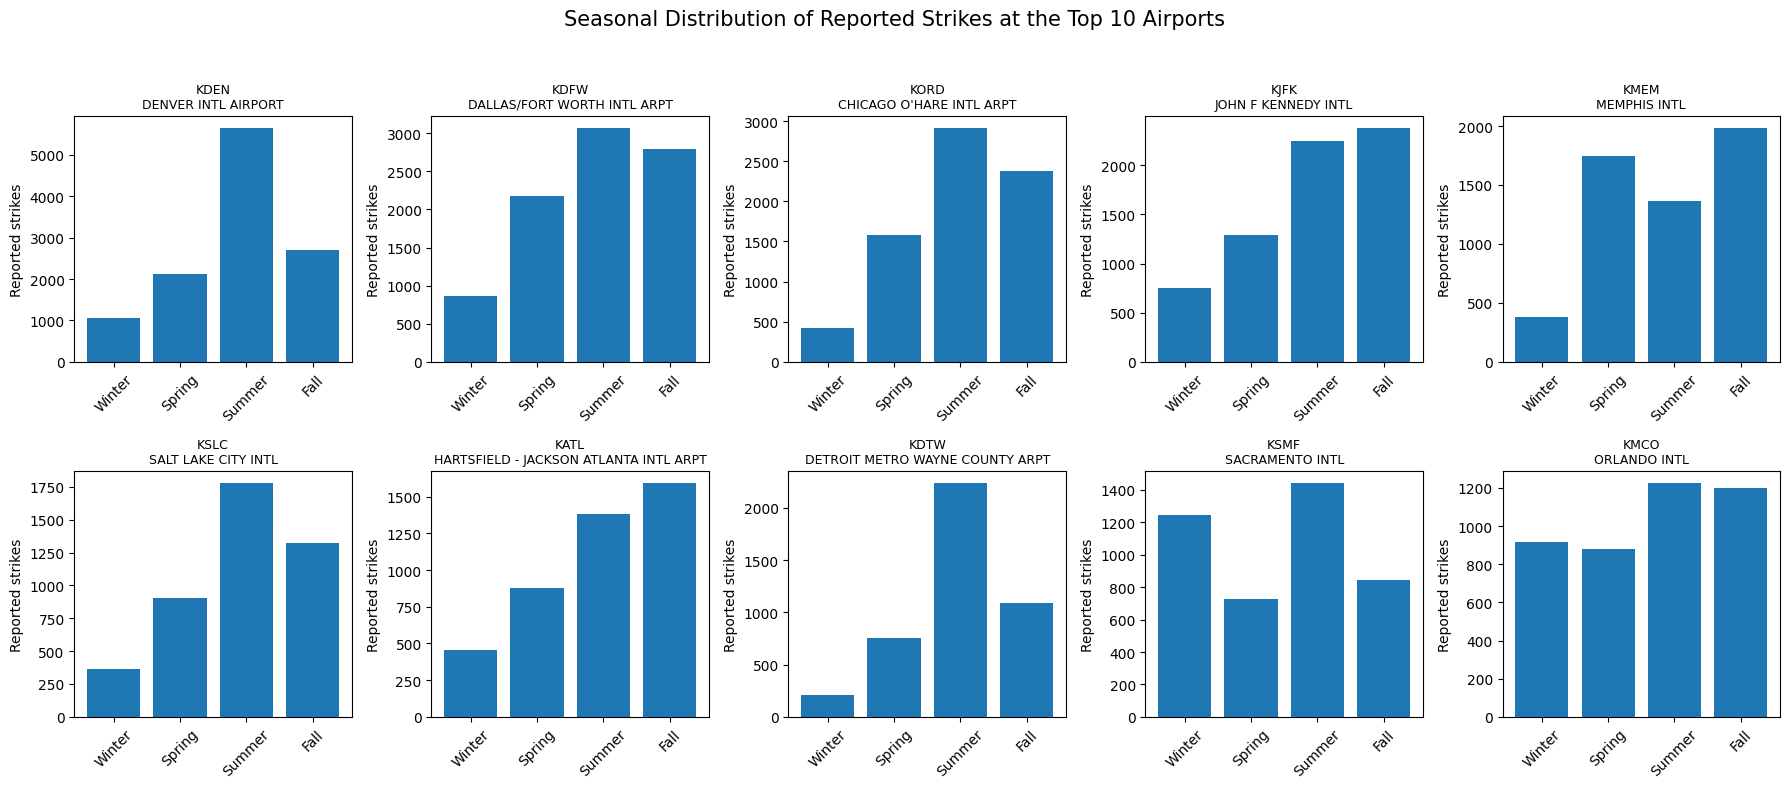

In [249]:
# subplot with 2 rows x 5 columns for the top 10 airports

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(18, 8),
    sharey=False
)

axes = axes.flatten()

for ax, airport_id in zip(
    axes,
    top_airport_ids
):
    airport_plot = (
        airport_season_summary[
            airport_season_summary[
                "AIRPORT_ID"
            ] == airport_id
        ]
        .set_index("SEASON")
        .reindex(season_order)
        .reset_index()
    )

    airport_name = (
        airport_plot["AIRPORT"]
        .dropna()
        .iloc[0]
    )

    bars = ax.bar(
        airport_plot["SEASON"],
        airport_plot["Reported_Strikes"]
    )

    ax.set_title(
        f"{airport_id}\n{airport_name}",
        fontsize=9
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.set_ylabel(
        "Reported strikes"
    )

plt.suptitle(
    "Seasonal Distribution of Reported Strikes at the Top 10 Airports",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

**Figure note.** Each panel shows the seasonal number of reported wildlife strikes for one of the ten airports with the largest reporting volumes. The vertical scales differ across panels to make airport-specific seasonal patterns easier to see.

#### Overall Observation

The airport-level panels show that seasonal strike patterns were not uniform across locations. Most northern and inland airports experienced strong Summer peaks, while several southern or coastal airports showed greater Fall activity or more balanced seasonal distributions.

The figure also reinforces that strike frequency and damage rate represent different dimensions of risk. High seasonal reporting volume did not necessarily correspond to a high proportion of damaging incidents. These differences may reflect local wildlife composition, migration patterns, climate, airport environment, aircraft activity, and reporting practices, although these factors are not directly measured in this descriptive comparison.

### 12.4 Sky and Precipitation Conditions

This subsection examines the reported sky and precipitation conditions associated with wildlife-strike incidents. The results are descriptive and reflect only records with available environmental information.

In [250]:
sky_summary = (
    analysis_df["SKY"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace("", "Unknown")
    .value_counts()
    .rename_axis("Sky_Condition")
    .reset_index(name="Reported_Strikes")
)

sky_summary["Percentage"] = (
    sky_summary["Reported_Strikes"]
    / len(analysis_df)
    * 100
)

display(sky_summary)

,Sky_Condition,Reported_Strikes,Percentage
0,Unknown,182057,52.989784
1,No Cloud,79019,22.999389
2,Some Cloud,55584,16.178362
3,Overcast,26910,7.832465


#### Observation

Sky-condition information was unavailable for 182,057 records, representing 52.99% of the analysis dataset. Among incidents with identified sky conditions, no-cloud conditions were reported most frequently, accounting for 79,019 records, followed by some-cloud conditions with 55,584 records and overcast conditions with 26,910 records.

Because more than half of the records had unknown sky conditions, the identified categories describe only the subset of incidents with available sky information.

In [251]:
precip_summary = (
    analysis_df["PRECIPITATION"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace("", "Unknown")
    .value_counts()
    .rename_axis("Precipitation")
    .reset_index(name="Reported_Strikes")
)

precip_summary["Percentage"] = (
    precip_summary["Reported_Strikes"]
    / len(analysis_df)
    * 100
)

display(precip_summary)

,Precipitation,Reported_Strikes,Percentage
0,Unknown,331030,96.350089
1,Rain,8750,2.546788
2,Fog,2730,0.794598
3,Snow,650,0.189190
4,"Fog, Rain",353,0.102745
5,"Rain, Snow",31,0.009023
6,"Fog, Snow",20,0.005821
7,"Fog, Rain, Snow",6,0.001746


#### Observation

Precipitation information was unavailable for 331,030 records, representing 96.35% of the analysis dataset. Among the identified precipitation categories, rain was reported most frequently, with 8,750 records, followed by fog with 2,730 records and snow with 650 records.

Combined precipitation conditions, such as fog with rain or rain with snow, were rarely reported. However, the extremely large `Unknown` category prevents the identified precipitation counts from representing the complete dataset.

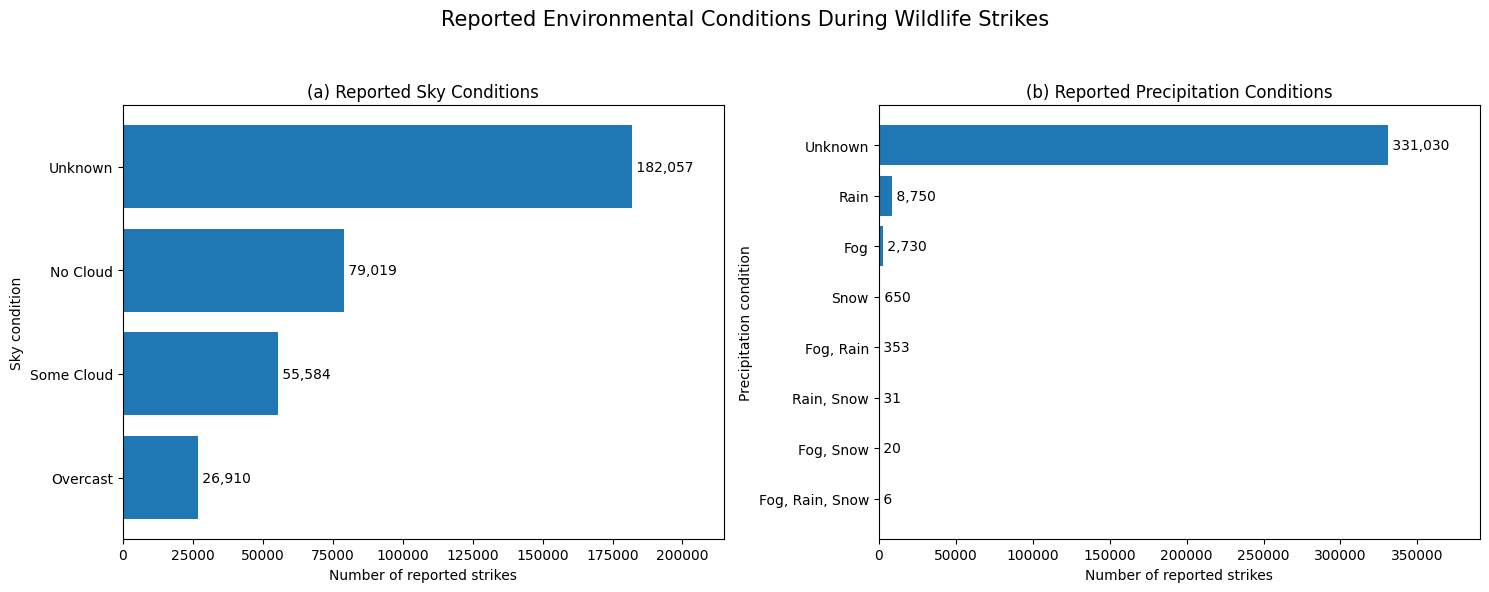

In [252]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

# --------------------------------------------------
# (a) Sky conditions
# --------------------------------------------------
plot_sky = sky_summary.sort_values(
    "Reported_Strikes",
    ascending=True
)

sky_bars = axes[0].barh(
    plot_sky["Sky_Condition"],
    plot_sky["Reported_Strikes"]
)

axes[0].set_title(
    "(a) Reported Sky Conditions"
)
axes[0].set_xlabel(
    "Number of reported strikes"
)
axes[0].set_ylabel(
    "Sky condition"
)

for bar in sky_bars:
    value = bar.get_width()

    axes[0].text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value):,}",
        ha="left",
        va="center"
    )

axes[0].set_xlim(
    0,
    plot_sky["Reported_Strikes"].max() * 1.18
)

# --------------------------------------------------
# (b) Precipitation conditions
# --------------------------------------------------
plot_precip = precip_summary.sort_values(
    "Reported_Strikes",
    ascending=True
)

precip_bars = axes[1].barh(
    plot_precip["Precipitation"],
    plot_precip["Reported_Strikes"]
)

axes[1].set_title(
    "(b) Reported Precipitation Conditions"
)
axes[1].set_xlabel(
    "Number of reported strikes"
)
axes[1].set_ylabel(
    "Precipitation condition"
)

for bar in precip_bars:
    value = bar.get_width()

    axes[1].text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value):,}",
        ha="left",
        va="center"
    )

axes[1].set_xlim(
    0,
    plot_precip["Reported_Strikes"].max() * 1.18
)

plt.suptitle(
    "Reported Environmental Conditions During Wildlife Strikes",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

#### Observation

The figure shows that environmental-condition information was incomplete, particularly for precipitation. More than half of the records lacked an identified sky condition, while precipitation information was unavailable for nearly the entire dataset.

Among records with known sky conditions, wildlife strikes were reported most often under no-cloud and some-cloud conditions. For precipitation, rain was the most frequently recorded condition, while fog, snow, and combined conditions appeared much less often.

Because the unknown categories are very large, these patterns should be interpreted as descriptions of the available records only. They do not show that clear skies or rain increased the likelihood of a wildlife strike.

## 13. Predictor Data Availability

This section summarizes missing or unknown information across the main variables that may be used to describe or predict aircraft-damage outcomes.

The outcome variables `INDICATED_DAMAGE` and `DAMAGE_LEVEL` are excluded because their completeness was already confirmed during dataset validation.

In [253]:
key_variables = [
    "INCIDENT_DATE",
    "INCIDENT_YEAR",
    "INCIDENT_MONTH",
    "INCIDENT_STATE",
    "AIRPORT_ID",
    "FAAREGION",
    "SPECIES",
    "SIZE",
    "NUM_STRUCK",
    "AC_CLASS",
    "AC_MASS",
    "TYPE_ENG",
    "NUM_ENGS",
    "PHASE_OF_FLIGHT",
    "WARNED",
    "TIME_OF_DAY",
    "HEIGHT",
    "SPEED",
    "DISTANCE"
]

key_variables = [
    column
    for column in key_variables
    if column in analysis_df.columns
]

In [254]:
unknown_values = {
    "",
    "UNKNOWN",
    "UNK",
    "ZZZZ",
    "NAN",
    "NONE"
}

missingness_records = []

for column in key_variables:

    series = analysis_df[column]

    missing_mask = series.isna()

    if (
        pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
        or isinstance(series.dtype, pd.CategoricalDtype)
    ):
        cleaned_series = (
            series
            .astype("string")
            .str.strip()
            .str.upper()
        )

        unavailable_mask = (
            missing_mask
            | cleaned_series.isin(unknown_values)
        )
    else:
        unavailable_mask = missing_mask

    unavailable_count = unavailable_mask.sum()

    missingness_records.append({
        "Variable": column,
        "Unavailable_Records": int(unavailable_count),
        "Available_Records": int(
            len(analysis_df) - unavailable_count
        ),
        "Unavailable_Percentage": (
            unavailable_count
            / len(analysis_df)
            * 100
        )
    })

missingness_summary = pd.DataFrame(
    missingness_records
)

missingness_summary = (
    missingness_summary
    .sort_values(
        "Unavailable_Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(missingness_summary)

,Variable,Unavailable_Records,Available_Records,Unavailable_Percentage
0,SPEED,237126,106444,69.018250
1,WARNED,213863,129707,62.247286
2,HEIGHT,172519,171051,50.213639
3,TIME_OF_DAY,149718,193852,43.577146
4,PHASE_OF_FLIGHT,135039,208531,39.304654
5,DISTANCE,115732,227838,33.685130
6,TYPE_ENG,97642,245928,28.419827
7,NUM_ENGS,97610,245960,28.410513
8,AC_MASS,97320,246250,28.326105
9,AC_CLASS,97190,246380,28.288267


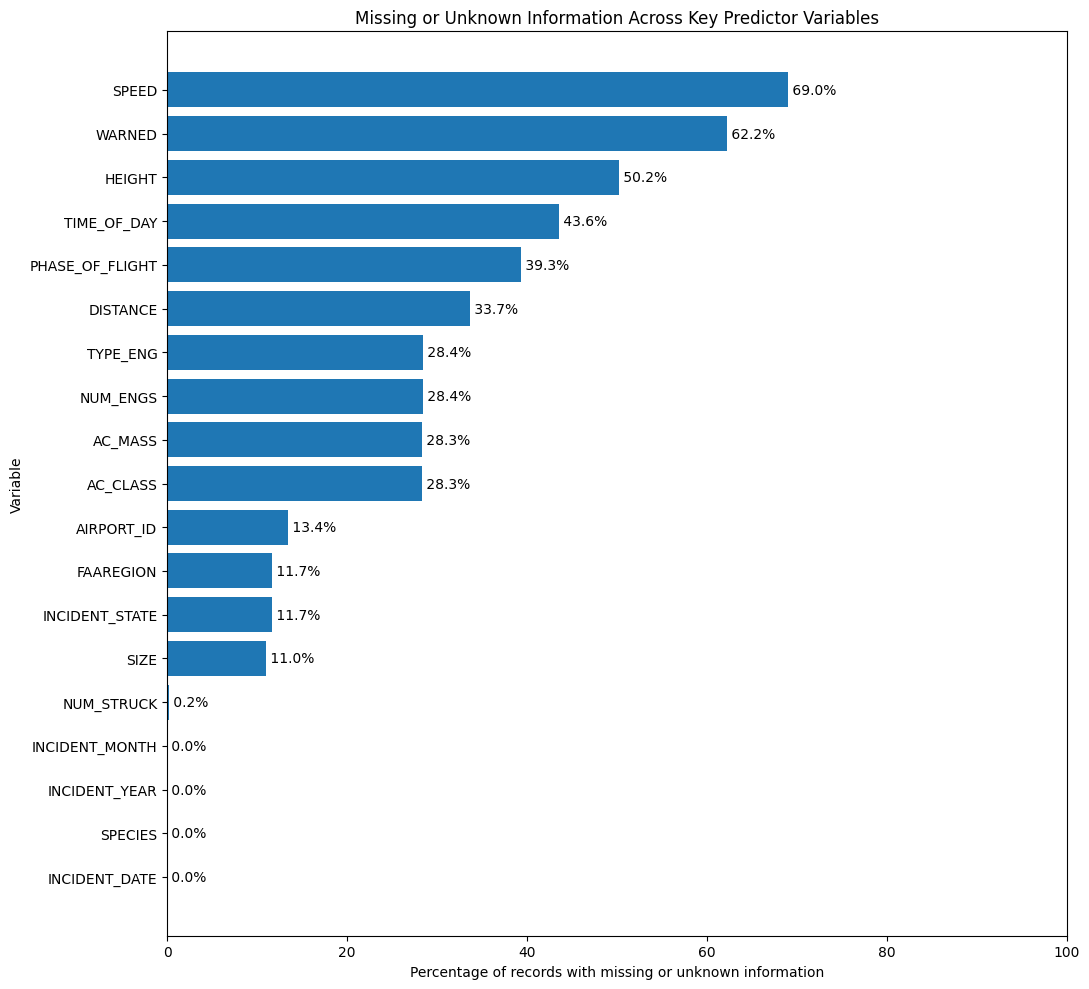

In [255]:
plot_missingness = (
    missingness_summary
    .sort_values(
        "Unavailable_Percentage",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(11, 10))

bars = ax.barh(
    plot_missingness["Variable"],
    plot_missingness["Unavailable_Percentage"]
)

ax.set_title(
    "Missing or Unknown Information Across Key Predictor Variables"
)
ax.set_xlabel(
    "Percentage of records with missing or unknown information"
)
ax.set_ylabel("Variable")

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.1f}%",
        ha="left",
        va="center"
    )

ax.set_xlim(
    0,
    max(
        100,
        plot_missingness["Unavailable_Percentage"].max()
        * 1.10
    )
)

plt.tight_layout()
plt.show()

**Note.**  Blank values in these fields may indicate that the corresponding outcome was not reported rather than conventional missing data.

#### Observation

Data availability varied substantially across the key analysis variables. The primary temporal and damage variables were complete, including incident date, year, month, species, indicated damage, and damage level. The number of wildlife struck was also nearly complete, with only 0.21% missing or unknown information.

Geographic variables and wildlife size had relatively low unavailable rates, ranging from approximately 11% to 13%. Aircraft characteristics showed moderate data limitations, with aircraft class, aircraft mass, engine type, and number of engines missing or unknown in approximately 28% of records.

Flight-context variables had the largest data gaps. Speed was unavailable in 69.02% of records, warning status in 62.25%, and height in 50.21%. Time of day, phase of flight, and distance also had substantial unavailable rates, ranging from 33.69% to 43.58%.

These limitations reduce the number of complete records available for detailed subgroup comparisons and predictive modelling involving flight-context and aircraft variables.

## 14. Key Descriptive Findings

This section summarizes the main findings from the descriptive analysis. The results describe patterns in reported wildlife-strike records and do not establish causal relationships.

### 14.1 Reporting and Damage Patterns

- The analysis included 343,570 reported wildlife-strike incidents from 1990 to 2025.
- Reported strike volume increased substantially over time, reaching 24,459 records in 2025.
- Aircraft damage was reported in 21,810 incidents, representing 6.35% of the analysis dataset.
- The reported damage rate declined over time, despite the increase in total strike-reporting volume.
- Among damaged incidents, minor damage represented 40.17%, undetermined severity represented 39.31%, substantial damage represented 20.11%, and destroyed aircraft represented 0.41%.

### 14.2 Temporal Patterns

- Reported strike volume was highest during Summer and Fall, particularly from July to October.
- August had the highest monthly reporting volume, while March had the highest monthly damage rate.
- Winter had the highest seasonal damage rate at 10.67%, while Summer had the lowest rate at 4.04%.
- Damage rates varied only slightly across days of the week.
- Dusk had the highest damage rate among records with an identified time of day.

### 14.3 Geographic Patterns

- Reported wildlife strikes were concentrated in the United States, especially across the eastern half of the country, the Midwest, the Southeast, Texas, Florida, and parts of the West Coast.
- Texas recorded the largest number of reported strikes among identified states.
- Denver International Airport had the highest reporting volume among the leading airports.
- High strike volume did not necessarily correspond to a high damage rate. Sacramento International Airport had the highest damage rate among the ten airports with the largest reporting volumes.
- Wildlife-species composition differed substantially across airports. No single species dominated at all leading airports.

### 14.4 Wildlife and Seasonal Relationships

- Small wildlife accounted for most reported strikes but had the lowest damage rate.
- Large wildlife had the highest damage rate at 32.61%.
- Damage rates increased as the reported number of wildlife struck increased.
- Most leading identified wildlife species were reported most frequently during Summer.
- Barn swallow showed the strongest Summer concentration, while gulls and red-tailed hawks displayed more balanced seasonal patterns.
- Airport-level species patterns reflected substantial geographic variation. Horned lark dominated at Denver, gull species were prominent at John F. Kennedy International Airport, and mourning dove ranked highly at several airports.

### 14.5 Aircraft and Flight Characteristics

- Airplanes accounted for most reported incidents, while helicopters had a higher damage rate.
- Smaller aircraft-mass categories had higher damage rates than the aircraft category with the largest reporting volume.
- Single-engine aircraft had the highest damage rate among the commonly reported engine-count categories.
- En route incidents had the highest damage rate among known phases of flight.
- Incidents without a reported warning had a higher damage rate than incidents with a warning, although this descriptive relationship does not establish a protective effect.

### 14.6 Component, Operational, and Financial Impacts

- Wing or rotor was the most frequently reported damaged aircraft component.
- External and forward-facing areas, including wing or rotor, windshield, nose, radome, and fuselage, were among the most frequently struck components.
- Lights had the highest component damage rate among reported component strikes.
- Engine 1 and Engine 2 had similar ingestion counts.
- Precautionary landing was the most frequently recorded operational effect among incidents with available effect information.
- Injuries and fatalities were rare relative to the full dataset.
- Inflation-adjusted repair and other costs were strongly right-skewed, with a small number of incidents producing very large financial losses.

### 14.7 Environmental Conditions and Data Availability

- Sky-condition information was unavailable for more than half of the records, while precipitation information was unavailable for more than 96%.
- Among records with identified environmental conditions, no-cloud and some-cloud skies were reported most often, while rain was the most frequently recorded precipitation condition.
- These environmental patterns do not demonstrate that specific weather conditions increased strike likelihood because of substantial missing information and the absence of exposure data.
- The primary temporal, wildlife-species, and damage variables were complete.
- Flight-context variables had the largest data gaps, particularly speed, warning status, and height.
- Aircraft characteristics had approximately 28% missing or unknown information, while geographic variables and wildlife size had approximately 11%–13%.

## 15. Conclusion

This descriptive analysis examined 343,570 reported FAA wildlife-strike incidents from 1990 to 2025. The dataset provided broad coverage of temporal, geographic, wildlife, aircraft, flight-context, component-damage, operational, human, and financial characteristics.

The results show that reporting frequency and aircraft damage risk followed different patterns. Categories with the largest numbers of reported strikes did not always have the highest damage rates. Summer and Fall recorded the largest strike volumes, while Winter had the highest seasonal damage rate. Small wildlife accounted for most reported incidents, but large wildlife and incidents involving multiple animals had substantially higher damage rates. Similar differences were observed across aircraft types, aircraft mass categories, phases of flight, airports, and damaged components.

Geographic and seasonal analyses also showed that wildlife-strike composition varied across airports and species. No single wildlife species dominated all leading airports, and most frequently reported species displayed distinct seasonal patterns. These findings highlight the importance of considering airport location, season, wildlife characteristics, aircraft configuration, and flight context together rather than evaluating strike counts alone.

The analysis also identified important data limitations. Several aircraft and flight-context variables contained substantial missing or unknown information, particularly speed, warning status, height, time of day, and phase of flight. Operational effects, injuries, fatalities, costs, sky conditions, and precipitation were available for only a subset of incidents or were affected by outcome-dependent reporting. In addition, the dataset contains reported wildlife strikes but does not include aircraft-movement or wildlife-population denominators. Therefore, the results cannot be interpreted as unconditional strike probabilities or causal effects.

Overall, this notebook provides a descriptive foundation for the next stages of the project. The identified patterns, data-quality limitations, and subgroup differences can guide statistical hypothesis testing, feature preparation, predictive modelling, chronological and airport-held-out validation, and Monte Carlo scenario analysis.